## **CAKE** (**C**onfidence in **A**ssignments via **K**-partition **E**nsembles)

**Pointwise Reliability Scores for Ensemble Clustering**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import silhouette_samples, confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import LabelEncoder

def sil_samples(X, labels, approximation=False, centers=None):
    """
    Compute silhouette scores for each point in the dataset,
    with approximate fast centroid-based computation option.
    """
    # Ensure arrays
    X = np.asarray(X)
    labels = np.asarray(labels)
    if X.ndim != 2:
       raise ValueError("X must be a 2D array of shape (n_samples, n_features).")
    if labels.ndim != 1 or labels.shape[0] != X.shape[0]:
       raise ValueError("labels must be a 1D array of length n_samples.")

    unique_labels, inv = np.unique(labels, return_inverse=True)
    k = unique_labels.size
    if k < 2:
       raise ValueError("Silhouette computation requires at least 2 clusters.")

    # Exact silhouette scores
    if approximation == False:
       silhouette_scores = silhouette_samples(X, labels=labels)
       return silhouette_scores

    # Centroid-based approximate silhouette scores
    n_samples, n_features = X.shape

    if centers is None:
       centers = np.array([X[inv == i].mean(axis=0) for i in range(k)], dtype=float)
    else:
       centers = np.asarray(centers, dtype=float)
       if centers.ndim != 2 or centers.shape[1] != n_features:
          raise ValueError(f"centers must have shape (k, d) with d={n_features}.")
       if centers.shape[0] != k:
          raise ValueError(f"centers.shape[0] must equal number of clusters k={k}.")
       if not np.array_equal(unique_labels, np.arange(k)):
          raise ValueError("When passing ndarray centers, labels must be dense 0..k-1.")

    # Squared distances to all centroids
    D_sq = euclidean_distances(X, centers, squared=True)

    # a(i): distance to own centroid
    a = np.sqrt(np.maximum(D_sq[np.arange(n_samples), inv], 0.0))

    # b(i): distance to nearest other centroid
    D_sq[np.arange(n_samples), inv] = np.inf
    b = np.sqrt(np.min(D_sq, axis=1))

    # Silhouette per point
    denom = np.maximum(np.maximum(a, b), 1e-12)
    s_point = (b - a) / denom

    # Singleton clusters -> silhouette = 0
    counts = np.bincount(inv, minlength=k).astype(int)
    s_point[counts[inv] < 2] = 0.0

    silhouette_scores = np.clip(s_point, -1.0, 1.0)

    return silhouette_scores

def sil_samples_stats(X, labels_list, approximation=False, centers_list=None):
    """
    Compute and aggregate silhouette scores across multiple clustering runs,
    returning per-sample mean and standard deviation of silhouette scores.
    """
    X = np.asarray(X)
    n_samples = X.shape[0]
    n_runs = len(labels_list)
    if n_runs < 2:
       raise ValueError("Clustering Ensemble must contain at least 2 partitions.")

    if centers_list is not None and len(centers_list) != n_runs:
       raise ValueError("centers_list must match the number of labelings in labels_list")

    # Initialize matrix to hold silhouette scores
    sil_scores = np.zeros((n_runs, n_samples), dtype=float)

    for i, labels in enumerate(labels_list):
        labels_arr = np.asarray(labels)
        centers = None
        if approximation and centers_list is not None:
           centers = centers_list[i]

        # Compute silhouette scores for this run
        sil_scores[i] = sil_samples(X, labels_arr, approximation=approximation, centers=centers)

    # Compute mean and standard deviation of sample-silhouette scores over the ensemble
    mean_sil_samples = sil_scores.mean(axis=0)
    std_sil_samples = sil_scores.std(axis=0)

    return mean_sil_samples, std_sil_samples

def align_labels(target, source):
    """
    Aligns the labels in "source" to match the labels in "target"
    using the Hungarian Algorithm based on a contingency matrix.

    Parameters:
    - target: array-like of shape (n_samples,)
              The reference label vector to align to.
    - source: array-like of shape (n_samples,)
              The label vector to be permuted for alignment.

    Returns:
    - aligned: np.ndarray of shape (n_samples,)
               The source labels, remapped to best match the target labels.
    """
    target = np.asarray(target)
    source = np.asarray(source)
    unique_target = np.unique(target)
    unique_source = np.unique(source)
    if len(unique_target) != len(unique_source):
       raise ValueError(
           f"Cannot align: Target has {len(unique_target)} clusters {unique_target.tolist()}, "
           f"but source has {len(unique_source)} clusters {unique_source.tolist()}"
       )
    # Encode labels to indices based on their unique values
    le_target = LabelEncoder().fit(unique_target)
    le_source = LabelEncoder().fit(unique_source)

    target_encoded = le_target.transform(target)
    source_encoded = le_source.transform(source)

    # Confusion matrix with indices aligned to encoded labels
    c_matrix = confusion_matrix(target_encoded, source_encoded)

    # Apply the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(-c_matrix)

    # Create mapping from source labels to target labels
    mapping = {
        le_source.classes_[src_col]: le_target.classes_[tgt_row]
        for tgt_row, src_col in zip(row_ind, col_ind)
    }
    # Remap source labels using the mapping
    aligned = np.vectorize(mapping.get)(source)

    return aligned

def pairwise_stability(labels_runs):
    """
    Computes per-point clustering stability across multiple runs by aligning labels
    pairwise using the Hungarian algorithm to account for label permutations.

    Parameters:
    - labels_runs: list of array-like
        List of label arrays from multiple clustering runs. Each array must have the
        same number of samples and clusters (unique labels).

    Returns:
    - stability: np.ndarray of shape (n_samples,)
        Per-point stability score between 0 and 1, indicating the fraction of run-pairs
        where the point's label matches after optimal alignment.

    Notes:
    - Requires all runs to have the same number of clusters (unique labels).
    - Label alignment is done pairwise between runs using the Hungarian algorithm.
    - High stability (~1) indicates stable cluster assignments across runs.
    """
    labels_runs = [np.asarray(labels) for labels in labels_runs]
    n_runs, n_samples = len(labels_runs), len(labels_runs[0])
    if n_runs < 2:
       raise ValueError("pairwise_stability needs at least 2 runs.")

    # Counters: How many run-pairs agree per point
    agreement_counts = np.zeros(n_samples, dtype=int)
    total_pairs = 0

    # For every unique pair of runs
    for r1 in range(n_runs):
        labels_r1 = labels_runs[r1]
        for r2 in range(r1+1, n_runs):
            labels_r2 = labels_runs[r2]

            # Align labels_r2 to labels_r1 using Hungarian
            aligned_r2 = align_labels(labels_r1, labels_r2)
            matches = (labels_r1 == aligned_r2)

            # Add matches to total per-point agreement count
            agreement_counts += matches
            total_pairs += 1

    return agreement_counts/total_pairs

def cake(X, labels_list, method='product', approximation=False, centers_list=None, geom_norm='clip'):
    """
    Compute a confidence score per point for clustering ensembles, defined as:
    stability_i * geometric_stability_i or
    2 * stability_i * geometric_stability_i / [stability_i + geometric_stability_i]
    where stability is the pairwise label agreement across runs,
    and mean_sil_i, std_sil_i are the statistics from sil_samples_stats.

    Parameters:
    - X: array-like, shape (n_samples, n_features)
    - labels_list: list of array-like, each of shape (n_samples,)
        A list of cluster labelings for the same dataset X.
    - approximation: bool, default=False
        Whether to use the approximate silhouette computation.
    - centers_list: list of pd.Series or array-like, optional
        If approximation=True, an optional list of centroids for each clustering.
    - method: str, default='product'
        'product' or 'harmonic_mean' for the formulation of the CAKE scores.
    - geo_norm: str, default='clip'
        - 'affine' (default): maps geom_raw in [-1,1] to [0,1] via (x+1)/2 (preserves negatives).
        - 'clip': max(mean_sil - std_sil, 0) clipped at 1 (original behavior; discards negatives).

    Returns:
    - cake_scores: np.ndarray, shape (n_samples,)
        The CAKE scores for each point.
    - stability: np.ndarray, shape (n_samples,)
        The stability scores for each point.
    - geom_stability: np.ndarray, shape (n_samples,)
        The silhouette-based reliability scores for each point (mean_sil_i - std_sil_i).
    - summary: pd.DataFrame
        Summary of above metrics per point in X.
    """
    # Compute silhouette statistics
    mean_sil, std_sil = sil_samples_stats(X, labels_list,
                                          approximation=approximation,
                                          centers_list=centers_list)

    # Assignment stability across the ensemble
    stability = pairwise_stability(labels_list)

    # Silhouette-based stability across the ensemble
    geom_raw = mean_sil - std_sil
    if geom_norm == 'clip':
       geom_stability = np.clip(mean_sil - std_sil, 0.0, 1.0)
    else:
       geom_stability = np.clip((geom_raw + 1) / 2, 0, 1) # preserves information for negative scores

    # Calculate confidence scores
    if method == 'product':
       cake_scores = stability * geom_stability
    elif method == 'harmonic_mean':
       num = 2.0 * stability * geom_stability
       denom = np.maximum(stability + geom_stability, 1e-8)
       cake_scores = num / denom
    else:
       raise ValueError(
           f"Unknown method: {method}. Use 'product' or 'harmonic_mean'."
       )

    # Summary DataFrame
    summary = pd.DataFrame({
        'Mean Silhouette': mean_sil,
        'STD Silhouette': std_sil,
        'Geometric Stability': geom_stability,
        'Assignment Stability': stability,
        'CAKE': cake_scores
    })

    return cake_scores, stability, geom_stability, summary

## Helpers

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import OrderedDict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.datasets import (
    load_iris,
    load_wine,
    load_breast_cancer,
    load_digits,
    fetch_openml,
    fetch_20newsgroups
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer
from tensorflow.keras.datasets import fashion_mnist
from scipy.stats import t
from sklearn.metrics import f1_score, adjusted_mutual_info_score
from scipy.stats import kendalltau, spearmanr
from sklearn.mixture import GaussianMixture
from sklearn.metrics import average_precision_score, roc_auc_score

from sklearn.decomposition import PCA
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
import time, gc

def clustering_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    accuracy = cm[row_ind, col_ind].sum() / np.sum(cm)
    return accuracy

def micro_sil(X, labels, approximation=False, centers=None):
    s = sil_samples(X, labels, approximation=approximation, centers=centers)
    return float(np.mean(s))

def macro_sil(X, labels, approximation=False, centers=None):
    labels = np.asarray(labels)
    s = sil_samples(X, labels, approximation=approximation, centers=centers)
    uniq = np.unique(labels)
    cluster_means = [s[labels == lab].mean() for lab in uniq]
    return float(np.mean(cluster_means))

def consensus_medoid_majority(labels_runs):
    if not labels_runs:
        raise ValueError("labels_runs must be a non-empty list of 1D arrays.")
    labs = [np.asarray(l) for l in labels_runs]
    R = len(labs)
    n = labs[0].shape[0]
    if any(len(l) != n for l in labs):
        raise ValueError("All runs must have the same number of samples.")

    ks = {np.unique(l).size for l in labs}
    if len(ks) != 1:
        raise ValueError(f"All runs must have the same number of clusters; got {sorted(ks)}.")

    # pairwise symmetric Hamming distances after alignment
    D = np.zeros((R, R), dtype=float)
    for i in range(R):
        li = labs[i]
        for j in range(i+1, R):
            lj = labs[j]
            aligned_j = align_labels(li, lj)
            d_ij = 1.0 - np.mean(aligned_j == li)
            aligned_i = align_labels(lj, li)
            d_ji = 1.0 - np.mean(aligned_i == lj)
            D[i, j] = D[j, i] = 0.5 * (d_ij + d_ji)

    medoid = int(np.argmin(D.sum(axis=1)))
    ref = labs[medoid]
    aligned = [align_labels(ref, l) for l in labs]   # align all runs to the medoid
    A = np.vstack(aligned)                           # (R, n)

    # majority vote per point; tie -> medoid label
    z_star = np.empty(n, dtype=ref.dtype)
    for i in range(n):
        counts = Counter(A[:, i])
        top = counts.most_common(2)
        if len(top) == 1 or top[0][1] > top[1][1]:
            z_star[i] = top[0][0]
        else:
            z_star[i] = ref[i]  # tie-break to medoid label

    agree = np.mean(A == z_star, axis=0)
    return z_star, agree

## Heatmaps

### Cake Product Formulation

CAKE Distribution:


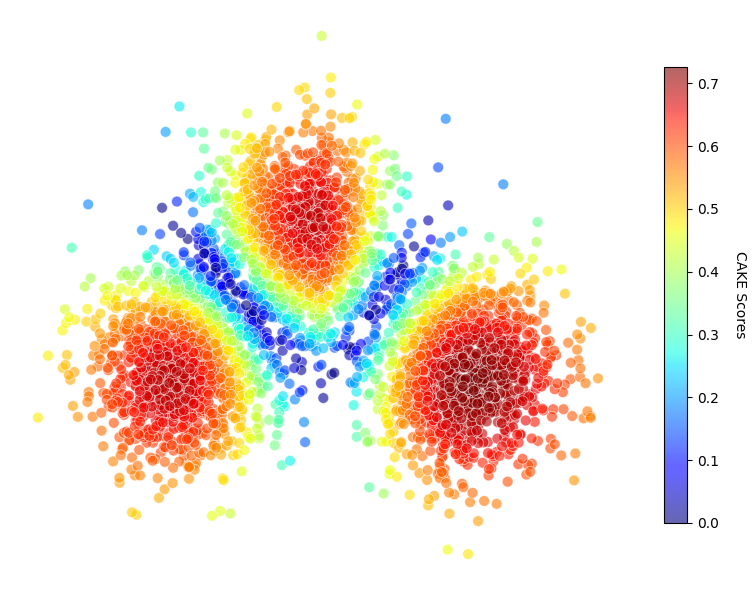


 CAKE Thresholds:


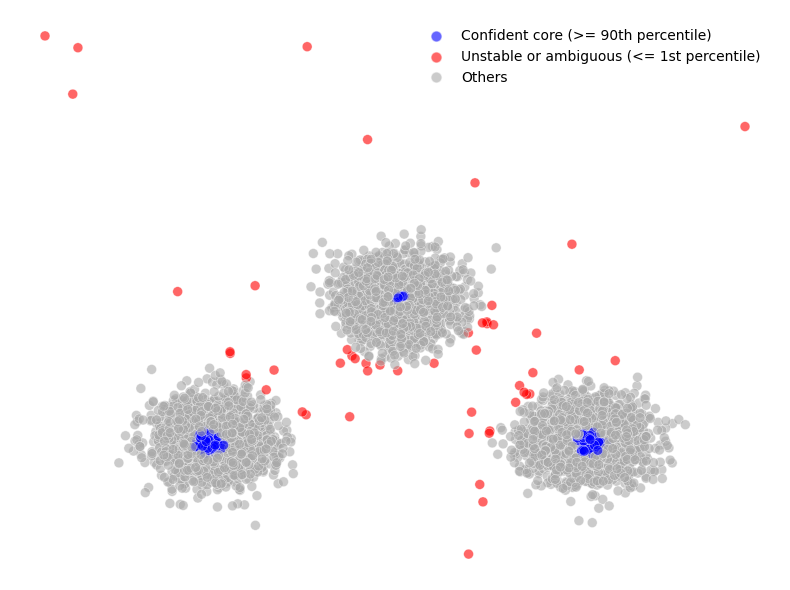

In [ ]:
X_core, _ = make_blobs(
    n_samples=4000,
    centers=[[0, 0], [5, 5], [12, 0]],
    cluster_std=2,
    random_state=42
)

labels_list = [KMeans(n_clusters=3, random_state=seed, n_init=1).fit_predict(X_core)
               for seed in range(0, 10)]

trust_scores,_,_, summary = cake(X_core, labels_list)

print('CAKE Distribution:')

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_core[:, 0], X_core[:, 1],
    c=trust_scores,
    cmap="jet",
    s=60,
    alpha=0.6,
    linewidth=0.6,
    edgecolor='w'
)

cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label('CAKE Scores', rotation=270, labelpad=20)

plt.xticks([])
plt.yticks([])

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print('\n CAKE Thresholds:')

X_base, _ = make_blobs(
    n_samples=5000,
    centers=[[0, 0], [5, 5], [10, 0]],
    cluster_std=0.8,
    random_state=42
)

np.random.seed(42)
outliers = np.random.uniform(low=-5, high=15, size=(20, 2))

X_core = np.vstack([X_base, outliers])

labels_list = [
    KMeans(n_clusters=3, random_state=seed, n_init=1).fit_predict(X_core)
    for seed in range(5)
]

trust_scores,_,_, summary = cake(X_core, labels_list)

low_thr = np.percentile(trust_scores, 1)
high_thr = np.percentile(trust_scores, 90)

colors = np.where(trust_scores > high_thr, 'blue',
         np.where(trust_scores < low_thr, 'red', 'darkgray'))

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_core[:, 0], X_core[:, 1],
    c=colors, s=50, alpha=0.6,
    edgecolors='white', linewidth=0.4
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax.set_xticks([])
ax.set_yticks([])

legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Confident core (>= 90th percentile)',
           markerfacecolor='blue', markersize=8, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Unstable or ambiguous (<= 1st percentile)',
           markerfacecolor='red', markersize=8, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Others',
           markerfacecolor='darkgray', markersize=8, alpha=0.6)
]
ax.legend(handles=legend_elems, loc='upper right', frameon=False, borderaxespad=1)

plt.tight_layout()
plt.show()

### Cake Harmonic Mean Formulation

CAKE Distribution:


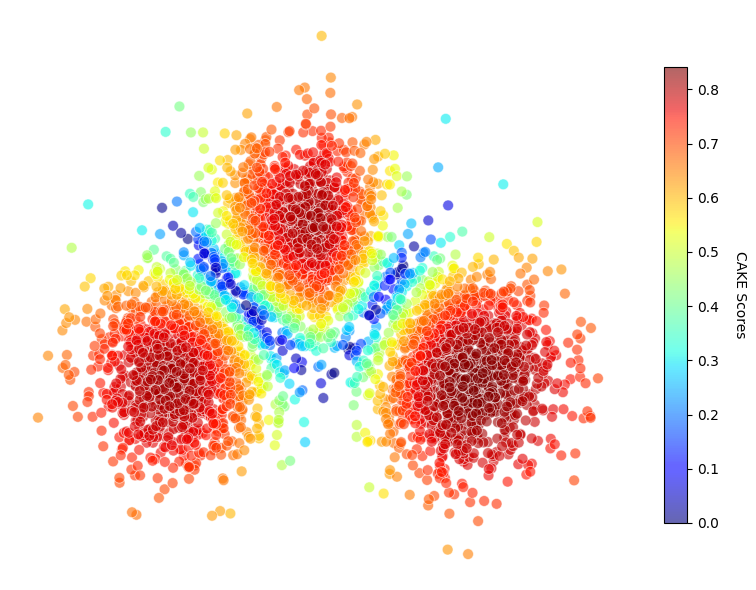


 CAKE Thresholds:


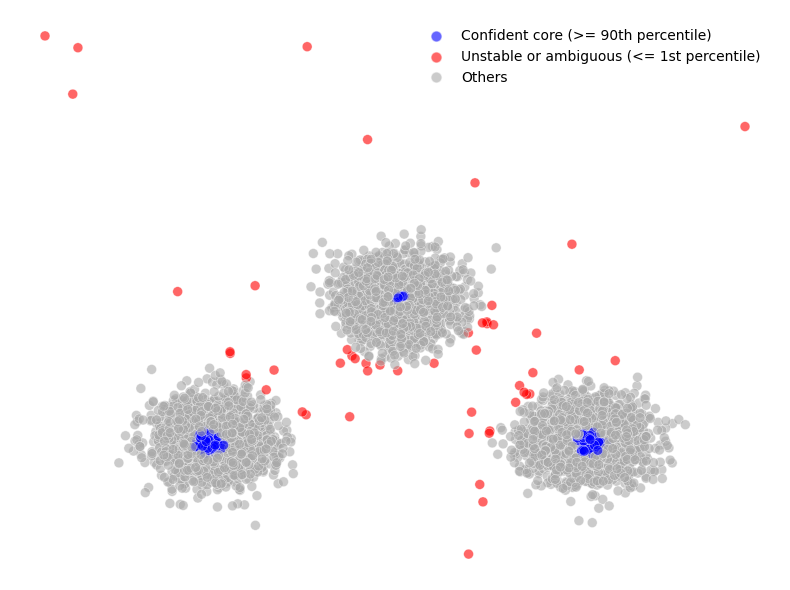

In [ ]:
X_core, _ = make_blobs(
    n_samples=4000,
    centers=[[0, 0], [5, 5], [12, 0]],
    cluster_std=2,
    random_state=42
)

labels_list = [KMeans(n_clusters=3, random_state=seed, n_init=1).fit_predict(X_core)
               for seed in range(0, 10)]

trust_scores,_,_, summary = cake(X_core, labels_list, method='harmonic_mean')

print('CAKE Distribution:')

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_core[:, 0], X_core[:, 1],
    c=trust_scores,
    cmap="jet",
    s=60,
    alpha=0.6,
    linewidth=0.6,
    edgecolor='w'
)

cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label('CAKE Scores', rotation=270, labelpad=20)

plt.xticks([])
plt.yticks([])

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print('\n CAKE Thresholds:')

X_base, _ = make_blobs(
    n_samples=5000,
    centers=[[0, 0], [5, 5], [10, 0]],
    cluster_std=0.8,
    random_state=42
)

np.random.seed(42)
outliers = np.random.uniform(low=-5, high=15, size=(20, 2))

X_core = np.vstack([X_base, outliers])

labels_list = [
    KMeans(n_clusters=3, random_state=seed, n_init=1).fit_predict(X_core)
    for seed in range(5)
]

trust_scores,_,_, summary = cake(X_core, labels_list, method='harmonic_mean')

low_thr = np.percentile(trust_scores, 1)
high_thr = np.percentile(trust_scores, 90)

colors = np.where(trust_scores > high_thr, 'blue',
         np.where(trust_scores < low_thr, 'red', 'darkgray'))

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_core[:, 0], X_core[:, 1],
    c=colors, s=50, alpha=0.6,
    edgecolors='white', linewidth=0.4
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax.set_xticks([])
ax.set_yticks([])

legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Confident core (>= 90th percentile)',
           markerfacecolor='blue', markersize=8, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Unstable or ambiguous (<= 1st percentile)',
           markerfacecolor='red', markersize=8, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Others',
           markerfacecolor='darkgray', markersize=8, alpha=0.6)
]
ax.legend(handles=legend_elems, loc='upper right', frameon=False, borderaxespad=1)

plt.tight_layout()
plt.show()

## Synthetic datasets: CAKE Filtering & Accuracy

#### **Synthetic Datasets: S1-S7**

In [ ]:
def load_synthetic_blobs():
    X, y = make_blobs(
        n_samples=4000,
        centers=[[0, 0], [5, 5], [12, 0]],
        cluster_std=2,
        random_state=42
    )
    return X, y

def load_clusters_with_noise():
    X_clusters, y_clusters = make_blobs(
        n_samples=3000, centers=[[0, 0], [5, 5], [10, 0]],
        cluster_std=1.0, random_state=10
    )
    rng = np.random.default_rng(42)
    X_noise = np.random.uniform(low=-10, high=15, size=(1500, 2))
    y_noise = [-1] * 1500  # Label -1 for noise

    X = np.vstack([X_clusters, X_noise])
    y = np.concatenate([y_clusters, y_noise])
    return X, y

def load_square_ring():
    centers = [[-3, -3], [-3, 3], [3, -3], [3, 3]]
    stds = [1.9] * 4
    X_list, y_list = [], []

    for i, c in enumerate(centers):
        X_i, _ = make_blobs(n_samples=750, centers=[c], cluster_std=stds[i], random_state=20+i)
        X_list.append(X_i)
        y_list.extend([i]*750)

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y

def load_synthetic_overlap():
    from sklearn.datasets import make_blobs
    import numpy as np

    centers = [[0, 0], [2, 0], [8, 8]]
    stds = [2, 2.3, 1.5]

    X_list, y_list = [], []
    for i, (c, s) in enumerate(zip(centers, stds)):
        X_i, _ = make_blobs(n_samples=1000, centers=[c], cluster_std=s, random_state=42+i)
        X_list.append(X_i)
        y_list.extend([i] * 1000)

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y

def load_high_density_contrast():
    centers = [[0, 0], [8, 0], [4, 8]]
    stds = [0.2, 3.0, 1.0]
    sizes = [1000, 2000, 1000]

    X_list, y_list = [], []
    for i, (c, s, n) in enumerate(zip(centers, stds, sizes)):
        X_i, _ = make_blobs(n_samples=n, centers=[c], cluster_std=s, random_state=100+i)
        X_list.append(X_i)
        y_list.extend([i] * n)

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y

def load_overlap_low_density():
    centers = [[0, 0], [4, 0], [8, 0]]
    stds = [0.4, 2.5, 0.4]
    sizes = [1000, 2000, 1000]

    X_list, y_list = [], []
    for i, (c, s, n) in enumerate(zip(centers, stds, sizes)):
        X_i, _ = make_blobs(n_samples=n, centers=[c], cluster_std=s, random_state=200+i)
        X_list.append(X_i)
        y_list.extend([i] * n)

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y

def load_imbalanced_blobs():
    centers = [[0, 0], [5, 5], [10, 0]]
    stds = [0.3, 1.5, 2.5]
    sizes = [500, 1000, 2500]

    X_list, y_list = [], []
    for i, (c, s, n) in enumerate(zip(centers, stds, sizes)):
        X_i, _ = make_blobs(n_samples=n, centers=[c], cluster_std=s, random_state=400+i)
        X_list.append(X_i)
        y_list.extend([i] * n)

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y

loaders_synth = {
    'S1':    load_synthetic_blobs,
    'S2':    load_synthetic_overlap,
    'S3':    load_clusters_with_noise,
    'S4':    load_square_ring,
    'S5':    load_high_density_contrast,
    'S6':    load_overlap_low_density,
    'S7':    load_imbalanced_blobs
}

#### **Visualization**

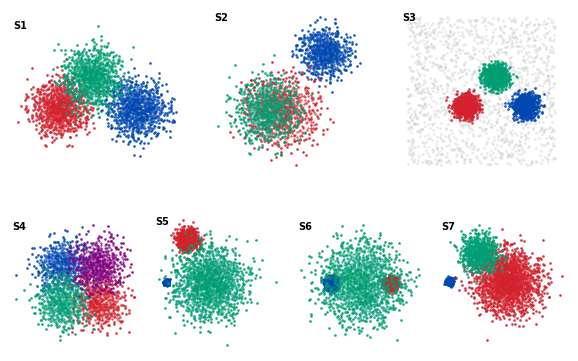

In [ ]:
PALETTE = ["#0048B1", "#D3212D", "#009E73", "purple"]

NOISE_COLOR = "#C8C8C8"

def _local_density(X, k=15):
    n = len(X)
    if n <= 2:
        return np.ones(n)
    k = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)
    dists, _ = nn.kneighbors(X)
    return 1.0 / (dists[:, 1:].mean(axis=1) + 1e-12)

def _draw_panel(ax, X, y, tag, colors, pad_ratio=0.05, rng=None):
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

    xmin, xmax = X[:,0].min(), X[:,0].max()
    ymin, ymax = X[:,1].min(), X[:,1].max()
    span = max(xmax - xmin, ymax - ymin); pad = pad_ratio * span
    ax.set_xlim(xmin - pad, xmax + pad); ax.set_ylim(ymin - pad, ymax + pad)

    if y is None:
        y = np.zeros(len(X), dtype=int)

    if np.any(y == -1):
        Xn = X[y == -1]
        ax.scatter(Xn[:,0], Xn[:,1], s=4, color=NOISE_COLOR, alpha=0.40, linewidths=0)

    labels = [lab for lab in np.unique(y) if lab != -1]
    if rng is None: rng = np.random.default_rng(0)
    labels = list(labels); rng.shuffle(labels)

    for j, lab in enumerate(labels):
        Xi = X[y == lab]
        dens = _local_density(Xi, k=min(15, len(Xi)-1))
        idx = np.argsort(dens)[::-1]
        Xi = Xi[idx]

        n = len(Xi)
        i1 = int(0.60*n); i2 = int(0.85*n)
        chunks = (Xi[:i1], Xi[i1:i2], Xi[i2:])
        alphas = (0.55, 0.72, 0.90)
        sizes  = (3.0, 3.0, 3.6)

        col = colors[j % len(colors)]
        for pts, a, s in zip(chunks, alphas, sizes):
            if len(pts) == 0: continue
            ax.scatter(pts[:,0], pts[:,1], s=s, color=col, alpha=a, linewidths=0)

    ax.text(0.02, 0.98, tag, transform=ax.transAxes,
            ha="left", va="top", fontsize=7, weight="bold")

def make_synth_grid(loaders, order=("S1","S2","S3","S4","S5","S6","S7"),
                           fig_size=(7.2, 4.6), seed=0, show=True):
    rng = np.random.default_rng(seed)

    fig = plt.figure(figsize=fig_size)
    gs = fig.add_gridspec(2, 1, hspace=0.18)
    gs_top = gs[0].subgridspec(1, 3, wspace=0.10)
    gs_bot = gs[1].subgridspec(1, 4, wspace=0.10)
    axes = [fig.add_subplot(gs_top[0, i]) for i in range(3)] + \
           [fig.add_subplot(gs_bot[0, i]) for i in range(4)]

    for ax, key in zip(axes, order):
        X, y = loaders[key]()
        _draw_panel(ax, X, y, key, PALETTE, rng=rng)

    if show:
        plt.show()
    else:
        plt.close(fig)

make_synth_grid(loaders_synth, show=True)

### Instance Removal via CAKE scores ranking &
### Impact on Clustering Quality

In [ ]:
results = []
ensemble_size = 20
n_trials = 10

def mean_ci_t(scores, confidence=0.95):
    scores = np.array(scores)
    n = len(scores)  # number of samples
    mean = np.mean(scores)  # sample mean
    se = np.std(scores, ddof=1) / np.sqrt(n)  # standard error of the mean
    h = se * t.ppf((1 + confidence) / 2., n - 1)  # margin of error - t critical value
    return f"{mean:.3f} [{mean - h:.4f}, {mean + h:.4f}]"

for name, loader in loaders_synth.items():
    print(f"\nProcessing dataset: {name}")
    X, y = loader()

    if not hasattr(X, "toarray"):
        X = SimpleImputer(strategy='mean').fit_transform(X)
    else:
        X = X.toarray()

    k = len(np.unique(y))

    print(f"\n - Creating the ensemble (R = {ensemble_size} partitions) on {name}")
    ensemble = [
        KMeans(n_clusters=k, init='random', n_init=1, random_state=seed).fit_predict(X)
        for seed in range(ensemble_size)
    ]

    # Filtering low X% based on CAKE (product or harmonic mean) and stability scores
    print(f"\n - Computing CAKE confidence estimation on {name}")
    # Cake product scores
    cake_product, stability, geom_stability, _ = cake(X, ensemble, method='product')

    # CAKE harmonic mean scores
    num = 2.0 * stability * geom_stability
    denom = np.maximum(stability + geom_stability, 1e-12)
    cake_harmonic_mean = num/denom

    # product cutoff -> keep_n
    cutoff_prod = np.percentile(cake_product, 30)
    cake_product_core_mask = cake_product > cutoff_prod

    # Keep_n derived from the product 30th percentile (top 70%)
    keep_n = int(cake_product_core_mask.sum())
    n_total = X.shape[0]

    print(f"\n - Applying CAKE filter: Retaining {keep_n} of {n_total} points")

    # top-keep_n for other scores (argsort = simple & clear)
    # CAKE harmonic mean filtering
    cake_harmonic_mean_core_mask = np.zeros(n_total, dtype=bool)
    cake_harmonic_mean_core_mask[np.argsort(cake_harmonic_mean)[-keep_n:]] = True

    # Stability only component filtering
    stability_core_mask = np.zeros(n_total, dtype=bool)
    stability_core_mask[np.argsort(stability)[-keep_n:]] = True

    # Silhouette component only filtering
    geom_stability_core_mask = np.zeros(n_total, dtype=bool)
    geom_stability_core_mask[np.argsort(geom_stability)[-keep_n:]] = True

    # Random baseline (same size as keep_n)
    rng = np.random.RandomState(0)  # reproducible
    random_core_mask = np.zeros(n_total, dtype=bool)
    random_core_mask[rng.choice(n_total, size=keep_n, replace=False)] = True

    # Consensus baseline
    z_star, agree_scores = consensus_medoid_majority(ensemble)
    consensus_core_mask = np.zeros(n_total, dtype=bool)
    consensus_core_mask[np.argsort(agree_scores)[-keep_n:]] = True

    for subset, mask in [
        ('full',              np.ones(n_total, dtype=bool)),
        ('random',            random_core_mask),
        ('consensus-agree',   consensus_core_mask),
        ('stability-only',    stability_core_mask),
        ('silhouette-only',   geom_stability_core_mask),
        ('CAKE-prod',         cake_product_core_mask),
        ('CAKE-hmean',        cake_harmonic_mean_core_mask),
    ]:
        X_sub, y_sub = (X, y) if subset == 'full' else (X[mask], y[mask])
        n_points = X_sub.shape[0]
        print(f" - Evaluating {subset.upper()} subset ({n_points} points)")
        ari_scores, nmi_scores, micro_scores, macro_scores, acc_scores, ami_scores = [], [], [], [], [], []

        for seed in range(n_trials):
            km = KMeans(n_clusters=k, init="random", n_init=1, random_state=seed)
            labels = km.fit_predict(X_sub)
            ari_scores.append(adjusted_rand_score(y_sub, labels))
            nmi_scores.append(normalized_mutual_info_score(y_sub, labels))
            micro_scores.append(micro_sil(X_sub, labels))
            acc_scores.append(clustering_accuracy(y_sub, labels))
            ami_scores.append(adjusted_mutual_info_score(y_sub, labels))

        results.append({
            'dataset':   name,
            'subset':    f"{subset} ({n_points})",
            'Silhouette': mean_ci_t(micro_scores),
            'ARI':       mean_ci_t(ari_scores),
            'NMI':       mean_ci_t(nmi_scores),
            'Accuracy':  mean_ci_t(acc_scores),
            'AMI':       mean_ci_t(ami_scores)
        })

    synth_df = pd.DataFrame(results).set_index(['dataset', 'subset'])


Processing dataset: S1

 - Creating the ensemble (R = 20 partitions) on S1

 - Computing CAKE confidence estimation on S1

 - Applying CAKE filter: Retaining 2800 of 4000 points
 - Evaluating FULL subset (4000 points)
 - Evaluating RANDOM subset (2800 points)
 - Evaluating CONSENSUS-AGREE subset (2800 points)
 - Evaluating STABILITY-ONLY subset (2800 points)
 - Evaluating SILHOUETTE-ONLY subset (2800 points)
 - Evaluating CAKE-PROD subset (2800 points)
 - Evaluating CAKE-HMEAN subset (2800 points)

Processing dataset: S2

 - Creating the ensemble (R = 20 partitions) on S2

 - Computing CAKE confidence estimation on S2

 - Applying CAKE filter: Retaining 2100 of 3000 points
 - Evaluating FULL subset (3000 points)
 - Evaluating RANDOM subset (2100 points)
 - Evaluating CONSENSUS-AGREE subset (2100 points)
 - Evaluating STABILITY-ONLY subset (2100 points)
 - Evaluating SILHOUETTE-ONLY subset (2100 points)
 - Evaluating CAKE-PROD subset (2100 points)
 - Evaluating CAKE-HMEAN subset (2100 

In [ ]:
def bold_group_col_max(df: pd.DataFrame):

    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    num_re = r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)'
    for ds, idx in df.groupby(level=0).groups.items():
        sub = df.loc[ds]
        means = sub.apply(
            lambda col: col.astype(str).str.extract(num_re, expand=False).astype(float)
        )
        for col in df.columns:
            m = means[col].max(skipna=True)
            styles.loc[(ds, means.index[means[col] == m]), col] = 'font-weight: bold'
    return styles

styled = synth_df.style.apply(bold_group_col_max, axis=None)

display(styled)

### CAKE Coverage - Clustering Accuracy

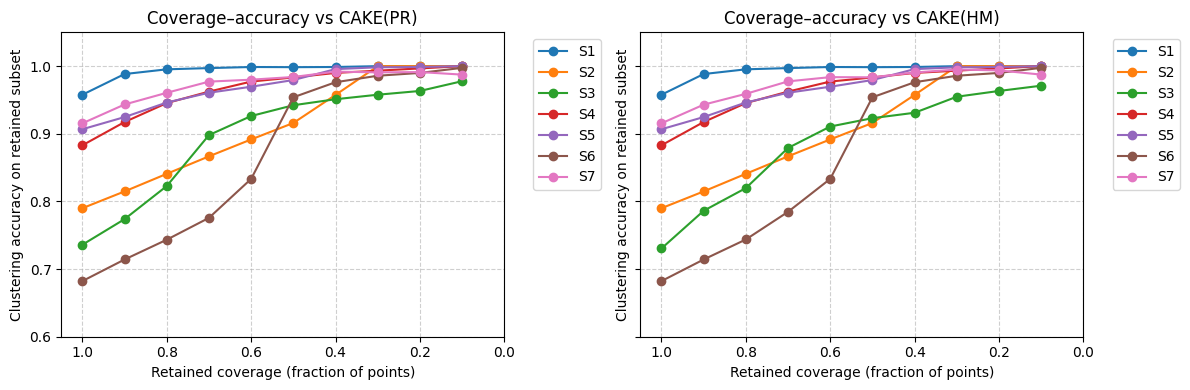

In [ ]:
def coverage_accuracy_curve(
    X,
    y,
    cake_method="product",
    ensemble_size=20,
    n_clusters=None,
    random_state=42,
    n_init_eval=10,
    coverages=None,
):
    """
    Compute a coverage–accuracy curve for CAKE on one dataset.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if n_clusters is None:
        n_clusters = len(np.unique(y))

    # ensemble of KMeans partitions
    rng = np.random.RandomState(random_state)
    labels_list = []
    for r in range(ensemble_size):
        km = KMeans(
            n_clusters=n_clusters,
            init="k-means++",
            n_init=1,
            random_state=rng.randint(0, 10**9),
        )
        labels_list.append(km.fit_predict(X))

    # CAKE scores
    cake_scores, _, _, _ = cake(
        X,
        labels_list,
        method=cake_method,
        approximation=False,
        centers_list=None,
        geom_norm="clip",
    )

    # reference KMeans for evaluation
    km_eval = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=n_init_eval,
        random_state=random_state,
    )
    y_pred = km_eval.fit_predict(X)

    # coverage levels -> accuracy on top-c CAKE points
    if coverages is None:
        coverages = np.linspace(0.1, 1.0, 10)

    coverages = np.asarray(coverages, dtype=float)
    order = np.argsort(cake_scores)[::-1]  # descending CAKE
    accuracies = []

    for c in coverages:
        m = max(1, int(round(len(X) * c)))
        idx = order[:m]
        acc = clustering_accuracy(y[idx], y_pred[idx])
        accuracies.append(acc)

    return coverages, np.asarray(accuracies)


def plot_coverage_accuracy(
    datasets,
    cake_method="product",
    ensemble_size=20,
    random_state=42,
    n_init_eval=10,
    coverages=None,
    ax=None,
    title=None, y_min=0.0
):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    for name, data in datasets.items():
        if callable(data):
            X, y = data()
        else:
            X, y = data

        X = np.asarray(X)
        y = np.asarray(y)

        cov, acc = coverage_accuracy_curve(
            X,
            y,
            cake_method=cake_method,
            ensemble_size=ensemble_size,
            n_clusters=len(np.unique(y)),
            random_state=random_state,
            n_init_eval=n_init_eval,
            coverages=coverages,
        )
        ax.plot(cov, acc, marker="o", label=name)

    ax.set_xlabel("Retained coverage (fraction of points)")
    ax.set_ylabel("Clustering accuracy on retained subset")
    if title is None:
        title = f"Coverage–accuracy vs CAKE ({cake_method})"
    ax.set_title(title)
    ax.set_xlim(1.05, 0)
    ax.set_ylim(y_min, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    return ax

def make_coverage_plots_for_appendix(loaders, ymin=0.0):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    plot_coverage_accuracy(
        loaders,
        cake_method="product",
        ensemble_size=20,
        random_state=42,
        n_init_eval=10,
        ax=axes[0],
        title="Coverage–accuracy vs CAKE(PR)", y_min=ymin
    )

    plot_coverage_accuracy(
        loaders,
        cake_method="harmonic_mean",
        ensemble_size=20,
        random_state=42,
        n_init_eval=10,
        ax=axes[1],
        title="Coverage–accuracy vs CAKE(HM)", y_min=ymin
    )

    plt.tight_layout()
    plt.show()

make_coverage_plots_for_appendix(loaders_synth, ymin=0.6)

## Real datasets: CAKE Filtering & Accuracy

#### **Real Datasets**

In [ ]:
# 20 News Groups
def load_20ng_bert(n_components=100):
    all_categories = [
            'alt.atheism',
            'comp.graphics',
            'comp.os.ms-windows.misc',
            'comp.sys.ibm.pc.hardware',
            'comp.sys.mac.hardware',
            'comp.windows.x',
            'misc.forsale',
            'rec.autos',
            'rec.motorcycles',
            'rec.sport.baseball',
            'rec.sport.hockey',
            'sci.crypt',
            'sci.electronics',
            'sci.med',
            'sci.space',
            'soc.religion.christian',
            'talk.politics.guns',
            'talk.politics.mideast',
            'talk.politics.misc',
            'talk.religion.misc']
    subset = fetch_20newsgroups(subset='all', categories=all_categories, remove=('headers', 'footers', 'quotes'))
    texts = subset.data
    labels = subset.target

    model = SentenceTransformer('all-MiniLM-L6-v2')
    X = model.encode(texts, show_progress_bar=True)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=n_components, random_state=42).fit_transform(X_scaled)

    return X_pca, labels

# Pendigits
def load_pendigits():
    data = fetch_openml('pendigits', version=1, as_frame=False)
    X = data.data
    y = LabelEncoder().fit_transform(data.target)
    return X, y

# Letter
def load_letter():
    data = fetch_openml('letter', version=1, as_frame=False)
    X = data.data
    y = LabelEncoder().fit_transform(data.target)
    X = StandardScaler().fit_transform(X)
    return X, y

# Fashion Mnist
def load_fashion_mnist_scaled():
    (X_train, y_train), _ = fashion_mnist.load_data()
    X = X_train.reshape((X_train.shape[0], -1)).astype(np.float32)
    return X, y_train

# Satimage
def load_satimage():
    X, y = fetch_openml('satimage', version=1, return_X_y=True, as_frame=False)
    y = LabelEncoder().fit_transform(y)
    pca = PCA(n_components=30, random_state=42)
    X_pca = pca.fit_transform(X)
    return X_pca, y

# Breast Cancer
def load_breast_cancer_processed():
    X, y = load_breast_cancer(return_X_y=True)
    X = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=10, random_state=42).fit_transform(X)
    return X_pca, y

loaders_real = {
    'iris':           lambda: load_iris(return_X_y=True),
    'breast_cancer':  load_breast_cancer_processed,
    'digits':         lambda: load_digits(return_X_y=True),
    '20newsgroups':   load_20ng_bert,
    'fashionmnist':   load_fashion_mnist_scaled,
    'pendigits':      load_pendigits,
    'letter':         load_letter,
    'satimage':       load_satimage
}

### Instance Removal via CAKE scores ranking &
### Impact on Clustering Quality

In [ ]:
results = []
ensemble_size = 20
n_trials = 10

def mean_ci_t(scores, confidence=0.95):
    scores = np.array(scores)
    n = len(scores)  # number of samples
    mean = np.mean(scores)  # sample mean
    se = np.std(scores, ddof=1) / np.sqrt(n)  # standard error of the mean
    h = se * t.ppf((1 + confidence) / 2., n - 1)  # margin of error - t critical value
    return f"{mean:.3f} [{mean - h:.4f}, {mean + h:.4f}]"

for name, loader in loaders_real.items():
    print(f"\nProcessing dataset: {name}")
    X, y = loader()

    if not hasattr(X, "toarray"):
        X = SimpleImputer(strategy='mean').fit_transform(X)
    else:
        X = X.toarray()

    k = len(np.unique(y))

    print(f"\n - Creating the ensemble (R = {ensemble_size} partitions) on {name}")
    ensemble = [
        KMeans(n_clusters=k, init='random', n_init=1, random_state=seed).fit_predict(X)
        for seed in range(ensemble_size)
    ]

    # Filtering low X% based on CAKE (product or harmonic mean) and stability scores
    print(f"\n - Computing CAKE confidence estimation on {name}")
    # Cake product scores
    cake_product, stability, geom_stability, _ = cake(X, ensemble, method='product')

    # CAKE harmonic mean scores
    num = 2.0 * stability * geom_stability
    denom = np.maximum(stability + geom_stability, 1e-12)
    cake_harmonic_mean = num/denom

    # product cutoff -> keep_n
    cutoff_prod = np.percentile(cake_product, 30)
    cake_product_core_mask = cake_product > cutoff_prod

    # Keep_n derived from the product 30th percentile (top 70%)
    keep_n = int(cake_product_core_mask.sum())
    n_total = X.shape[0]

    print(f"\n - Applying CAKE filter: Retaining {keep_n} of {n_total} points")

    # top-keep_n for other scores (argsort = simple & clear)
    # CAKE harmonic mean filtering
    cake_harmonic_mean_core_mask = np.zeros(n_total, dtype=bool)
    cake_harmonic_mean_core_mask[np.argsort(cake_harmonic_mean)[-keep_n:]] = True

    # Stability only component filtering
    stability_core_mask = np.zeros(n_total, dtype=bool)
    stability_core_mask[np.argsort(stability)[-keep_n:]] = True

    # Silhouette component only filtering
    geom_stability_core_mask = np.zeros(n_total, dtype=bool)
    geom_stability_core_mask[np.argsort(geom_stability)[-keep_n:]] = True

    # Random baseline (same size as keep_n)
    rng = np.random.RandomState(0)  # reproducible
    random_core_mask = np.zeros(n_total, dtype=bool)
    random_core_mask[rng.choice(n_total, size=keep_n, replace=False)] = True

    # Consensus baseline
    z_star, agree_scores = consensus_medoid_majority(ensemble)
    consensus_core_mask = np.zeros(n_total, dtype=bool)
    consensus_core_mask[np.argsort(agree_scores)[-keep_n:]] = True

    for subset, mask in [
        ('full',              np.ones(n_total, dtype=bool)),
        ('random',            random_core_mask),
        ('consensus-agree',   consensus_core_mask),
        ('stability-only',    stability_core_mask),
        ('silhouette-only',   geom_stability_core_mask),
        ('CAKE-prod',         cake_product_core_mask),
        ('CAKE-hmean',        cake_harmonic_mean_core_mask),
    ]:
        X_sub, y_sub = (X, y) if subset == 'full' else (X[mask], y[mask])
        n_points = X_sub.shape[0]
        print(f" - Evaluating {subset.upper()} subset ({n_points} points)")
        ari_scores, nmi_scores, micro_scores, macro_scores, acc_scores, ami_scores = [], [], [], [], [], []

        for seed in range(n_trials):
            km = KMeans(n_clusters=k, init="random", n_init=1, random_state=seed)
            labels = km.fit_predict(X_sub)
            ari_scores.append(adjusted_rand_score(y_sub, labels))
            nmi_scores.append(normalized_mutual_info_score(y_sub, labels))
            micro_scores.append(micro_sil(X_sub, labels))
            acc_scores.append(clustering_accuracy(y_sub, labels))
            ami_scores.append(adjusted_mutual_info_score(y_sub, labels))

        results.append({
            'dataset':   name,
            'subset':    f"{subset} ({n_points})",
            'Silhouette': mean_ci_t(micro_scores),
            'ARI':       mean_ci_t(ari_scores),
            'NMI':       mean_ci_t(nmi_scores),
            'Accuracy':  mean_ci_t(acc_scores),
            'AMI':       mean_ci_t(ami_scores)
        })

    real_df = pd.DataFrame(results).set_index(['dataset', 'subset'])


Processing dataset: iris

 - Creating the ensemble (R = 20 partitions) on iris

 - Computing CAKE confidence estimation on iris

 - Applying CAKE filter: Retaining 105 of 150 points
 - Evaluating FULL subset (150 points)
 - Evaluating RANDOM subset (105 points)
 - Evaluating CONSENSUS-AGREE subset (105 points)
 - Evaluating STABILITY-ONLY subset (105 points)
 - Evaluating SILHOUETTE-ONLY subset (105 points)
 - Evaluating CAKE-PROD subset (105 points)
 - Evaluating CAKE-HMEAN subset (105 points)

Processing dataset: breast_cancer

 - Creating the ensemble (R = 20 partitions) on breast_cancer

 - Computing CAKE confidence estimation on breast_cancer

 - Applying CAKE filter: Retaining 398 of 569 points
 - Evaluating FULL subset (569 points)
 - Evaluating RANDOM subset (398 points)
 - Evaluating CONSENSUS-AGREE subset (398 points)
 - Evaluating STABILITY-ONLY subset (398 points)
 - Evaluating SILHOUETTE-ONLY subset (398 points)
 - Evaluating CAKE-PROD subset (398 points)
 - Evaluating CA

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]


 - Creating the ensemble (R = 20 partitions) on 20newsgroups

 - Computing CAKE confidence estimation on 20newsgroups

 - Applying CAKE filter: Retaining 13192 of 18846 points
 - Evaluating FULL subset (18846 points)
 - Evaluating RANDOM subset (13192 points)
 - Evaluating CONSENSUS-AGREE subset (13192 points)
 - Evaluating STABILITY-ONLY subset (13192 points)
 - Evaluating SILHOUETTE-ONLY subset (13192 points)
 - Evaluating CAKE-PROD subset (13192 points)
 - Evaluating CAKE-HMEAN subset (13192 points)

Processing dataset: fashionmnist

 - Creating the ensemble (R = 20 partitions) on fashionmnist

 - Computing CAKE confidence estimation on fashionmnist

 - Applying CAKE filter: Retaining 42000 of 60000 points
 - Evaluating FULL subset (60000 points)
 - Evaluating RANDOM subset (42000 points)
 - Evaluating CONSENSUS-AGREE subset (42000 points)
 - Evaluating STABILITY-ONLY subset (42000 points)
 - Evaluating SILHOUETTE-ONLY subset (42000 points)
 - Evaluating CAKE-PROD subset (42000 poi

In [ ]:
styled_real = real_df.style.apply(bold_group_col_max, axis=None)

display(styled_real)

### CAKE Coverage - Clustering Accuracy

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

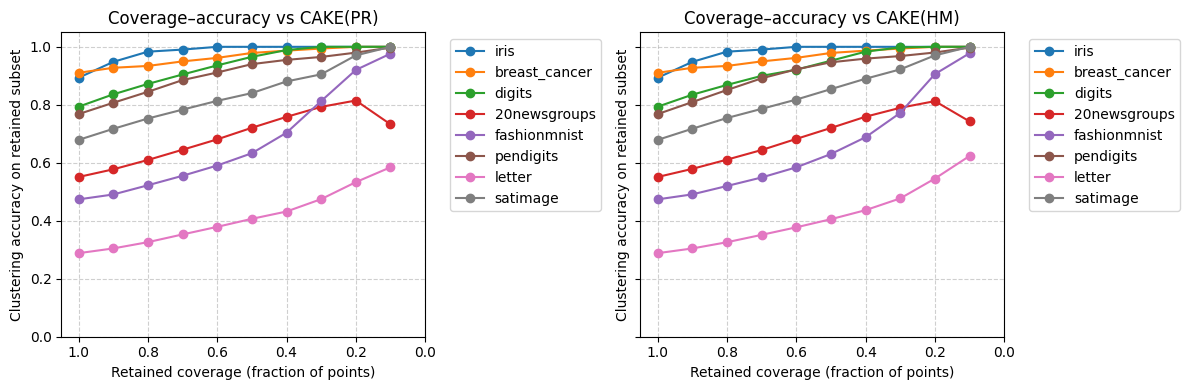

In [ ]:
make_coverage_plots_for_appendix(loaders_real)

## CAKE on Misspecified $k$ $\rightarrow$ $k$ $\neq$ ground-truth cluster count

### - Misspecified $k$: Synthetic Datasets

[k-misspec] S1
[k-misspec] S2
[k-misspec] S3
[k-misspec] S4
[k-misspec] S5
[k-misspec] S6
[k-misspec] S7


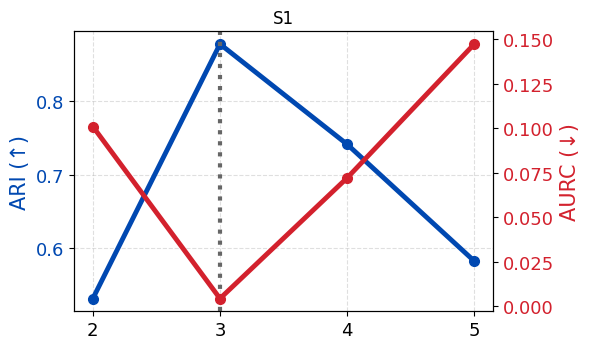

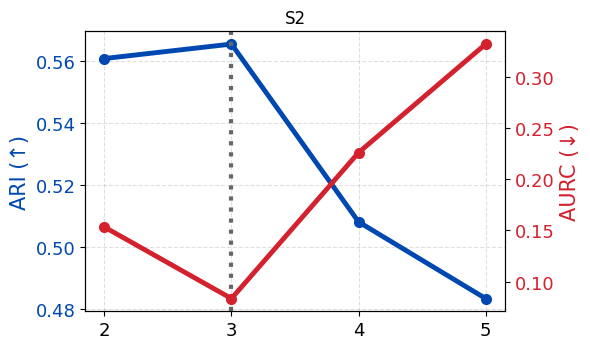

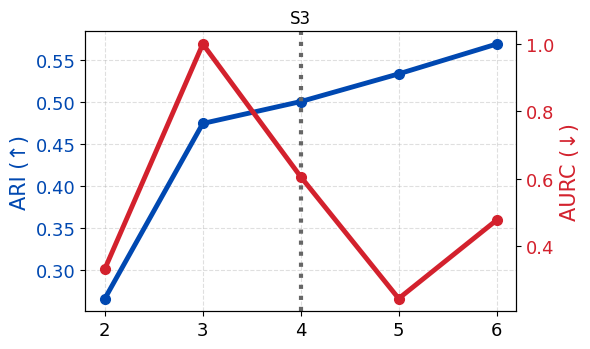

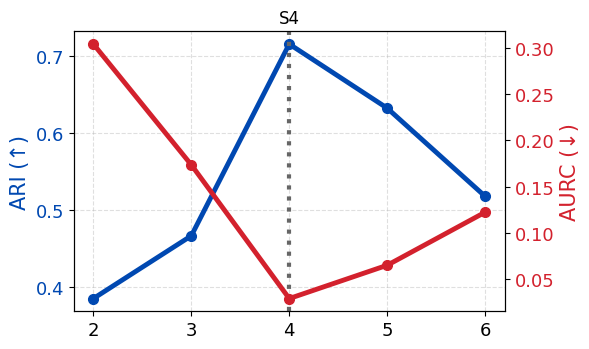

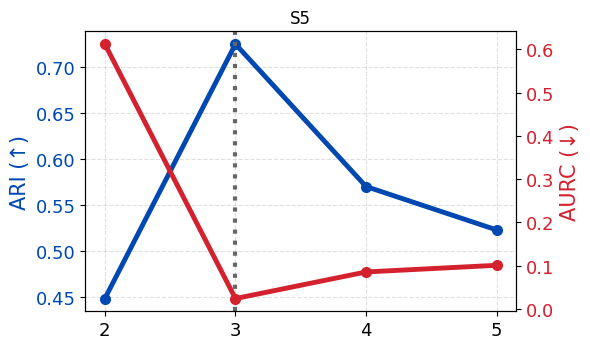

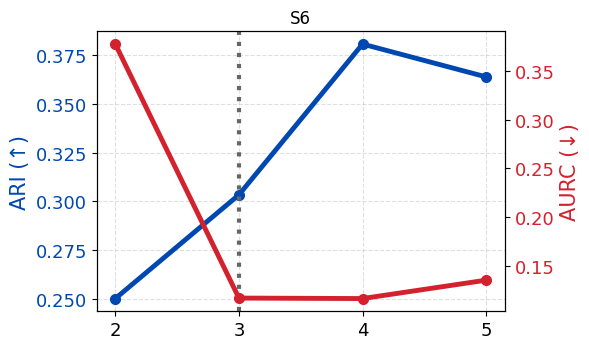

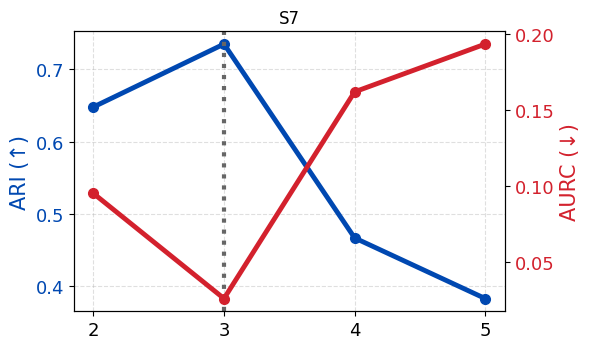

In [ ]:
def align_to_truth(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    r, c = linear_sum_assignment(-cm)
    mapping = {c_: r_ for r_, c_ in zip(r, c)}
    return np.vectorize(mapping.get)(y_pred)

def clustering_accuracy(y_true, y_pred):
    y_aligned = align_to_truth(y_true, y_pred)
    return float((y_aligned == y_true).mean())

def km_labels(X, k, init="k-means++", n_init=10, seed=0):
    return KMeans(n_clusters=k, init=init, n_init=n_init, random_state=seed).fit_predict(X)

def risk_coverage(y_bin, s, steps=201):
    order = np.argsort(s)[::-1]
    y_sorted = y_bin[order]
    cum_correct = np.cumsum(y_sorted)
    n = len(s)
    idx = np.linspace(1, n, steps, dtype=int)
    coverage = idx / n
    acc = cum_correct[idx - 1] / idx
    risk = 1.0 - acc
    aurc = float(np.trapezoid(risk, coverage))
    return aurc

def k_grid(k):
    return sorted(set([max(2, k-2), max(2, k-1), k, k+1, k+2]))

def eval_kmisspec(X, y, kprime, R=30, return_meancake=False):
    # Ensemble at k'
    ensemble = [KMeans(n_clusters=kprime, init="random", n_init=1, random_state=seed).fit_predict(X)
                for seed in range(R)]
    cake_hm, _, _, _ = cake(X, ensemble, method='harmonic_mean')

    # Reference k-means++ at k'
    km = KMeans(n_clusters=kprime, init="k-means++", n_init=10, random_state=0).fit(X)
    yhat = km.labels_
    ari = adjusted_rand_score(y, yhat)
    acc = clustering_accuracy(y, yhat)

    # AURC (ranking quality of CAKE for this k')
    ycorr = (align_to_truth(y, yhat) == y).astype(int)
    aurc = risk_coverage(ycorr, cake_hm)

    out = dict(ARI=float(ari), ACC=float(acc), AURC=float(aurc))
    if return_meancake:
        out["MeanCAKE"] = float(np.mean(cake_hm))
    return out

# run on synthetic loaders
rows = []
for name, loader in loaders_synth.items():
    print(f"[k-misspec] {name}")
    X, y = loader()
    X = SimpleImputer(strategy='mean').fit_transform(X) if not hasattr(X, "toarray") else X.toarray()
    k_true = len(np.unique(y))
    for kp in k_grid(k_true):
        out = eval_kmisspec(X, y, kp, R=30, return_meancake=False)
        out.update(dataset=name, k_true=int(k_true), k_prime=int(kp))
        rows.append(out)

dfK = pd.DataFrame(rows)
#display(dfK.round(4))

#  plotting: ARI (blue) + AURC (red) per dataset
def plot_ari_aurc(df, dataset_name):
    sub = df[df["dataset"]==dataset_name].sort_values("k_prime")
    x = sub["k_prime"].values
    k_true = int(sub["k_true"].iloc[0])

    fig, ax1 = plt.subplots(figsize=(6,3.6))
    ax2 = ax1.twinx()

    l1 = ax1.plot(x, sub["ARI"].values, marker='o', linewidth=3.5, markersize=7, color='#0048B1', label="ARI (↑)")
    ax1.set_ylabel("ARI (↑)", color='#0048B1', fontsize=15)
    ax1.tick_params(axis='y', labelcolor='#0048B1', labelsize=13)

    l2 = ax2.plot(x, sub["AURC"].values, marker='o', linewidth=3.5, markersize=7, color='#D3212D', label="AURC (↓)")
    ax2.set_ylabel("AURC (↓)", color='#D3212D', fontsize=15)
    ax2.tick_params(axis='y', labelcolor='#D3212D', labelsize=13)

    ax1.set_xlabel("")
    ax1.axvline(k_true, linestyle=':', color='0.4', linewidth=3, label=f"k_true={k_true}")
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax1.set_title(dataset_name)
    ax1.set_xticks(x)
    ax1.tick_params(axis='x', labelsize=13)
    plt.tight_layout(); plt.show()

for ds in dfK["dataset"].unique():
    plot_ari_aurc(dfK, ds)

### - Misspecified $k$: Real Datasets

[k-misspec] iris
[k-misspec] breast_cancer
[k-misspec] digits
[k-misspec] 20newsgroups


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

[k-misspec] fashionmnist
[k-misspec] pendigits
[k-misspec] letter
[k-misspec] satimage


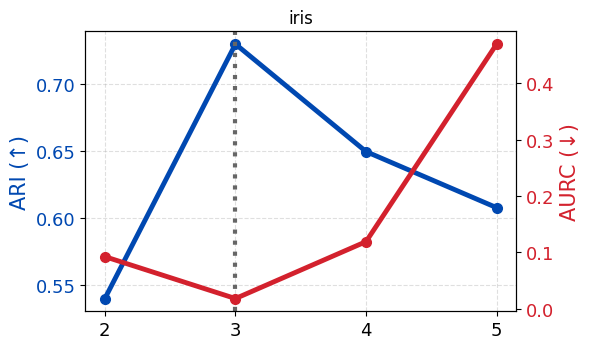

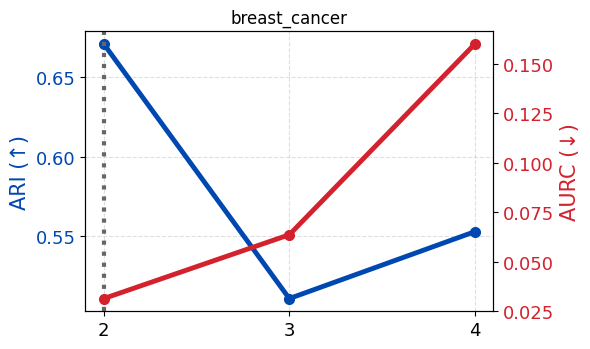

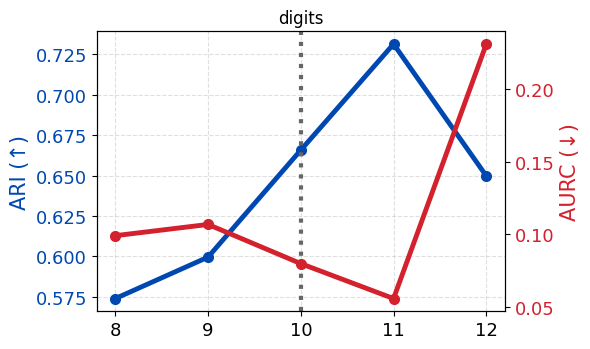

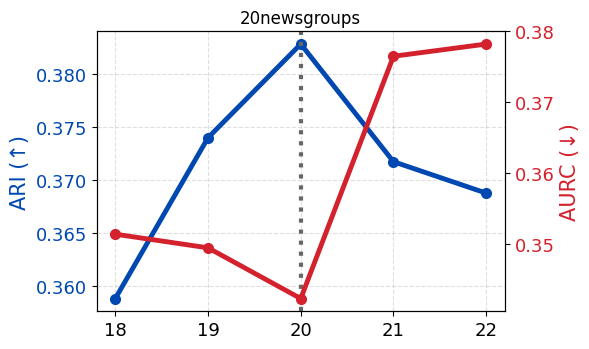

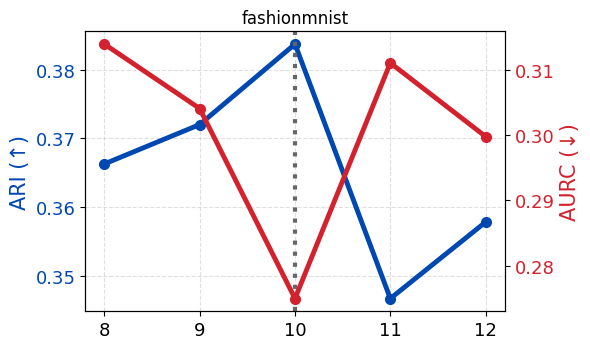

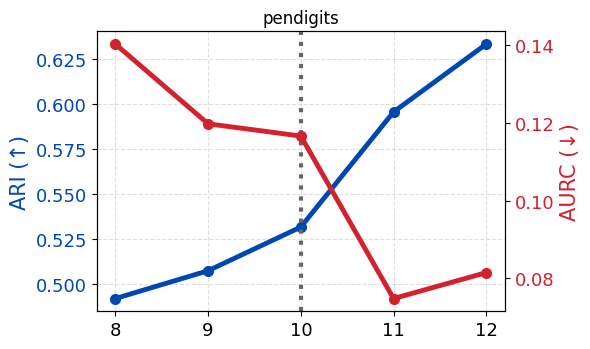

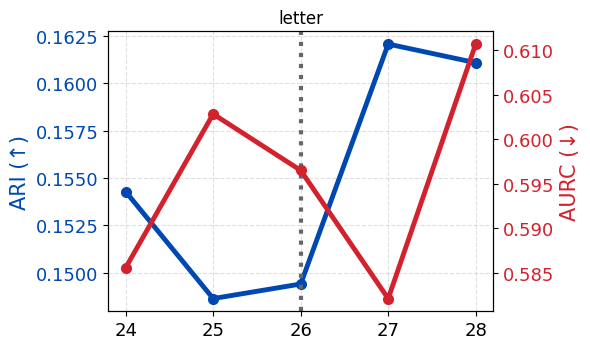

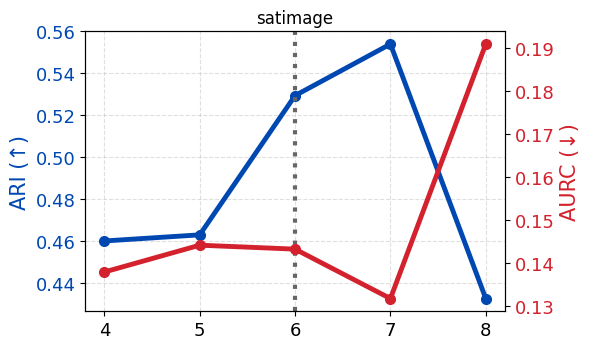

In [ ]:
rows = []
for name, loader in loaders_real.items():
    print(f"[k-misspec] {name}")
    X, y = loader()
    X = SimpleImputer(strategy='mean').fit_transform(X) if not hasattr(X, "toarray") else X.toarray()
    k_true = len(np.unique(y))
    for kp in k_grid(k_true):
        out = eval_kmisspec(X, y, kp, R=30, return_meancake=False)
        out.update(dataset=name, k_true=int(k_true), k_prime=int(kp))
        rows.append(out)

dfK = pd.DataFrame(rows)
#display(dfK.round(4))

#  plotting: ARI (blue) + AURC (red) on the same axis per dataset
def plot_ari_aurc(df, dataset_name):
    sub = df[df["dataset"]==dataset_name].sort_values("k_prime")
    x = sub["k_prime"].values
    k_true = int(sub["k_true"].iloc[0])

    fig, ax1 = plt.subplots(figsize=(6,3.6))
    ax2 = ax1.twinx()

    l1 = ax1.plot(x, sub["ARI"].values, marker='o', linewidth=3.5, markersize=7, color='#0048B1', label="ARI (↑)")
    ax1.set_ylabel("ARI (↑)", color='#0048B1', fontsize=15)
    ax1.tick_params(axis='y', labelcolor='#0048B1', labelsize=13)

    l2 = ax2.plot(x, sub["AURC"].values, marker='o', linewidth=3.5, markersize=7, color='#D3212D', label="AURC (↓)")
    ax2.set_ylabel("AURC (↓)", color='#D3212D', fontsize=15)
    ax2.tick_params(axis='y', labelcolor='#D3212D', labelsize=13)

    ax1.set_xlabel("")
    ax1.axvline(k_true, linestyle=':', color='0.4', linewidth=3, label=f"k_true={k_true}")
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax1.set_title(dataset_name)
    ax1.set_xticks(x)
    ax1.tick_params(axis='x', labelsize=13)
    plt.tight_layout(); plt.show()

for ds in dfK["dataset"].unique():
    plot_ari_aurc(dfK, ds)

## Convergence $\rightarrow$ CAKE vs. Ensemble size $R$ (Real Datasets)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

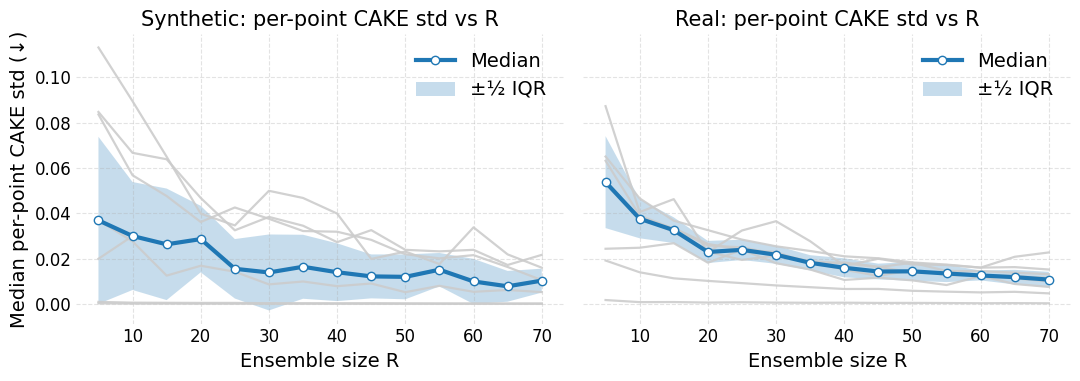

In [ ]:
def cake_hmean_approx(X, labels, centers):
    cake_scores, stability, geom, _ = cake(
        X, labels_list=labels, method='harmonic_mean',
        approximation=True, centers_list=centers
    )
    return cake_scores

def cake_r_variability_approx(X, y, k,
                              R_grid=(5,10,20,40),
                              R_pool=200,        # pool for drawing sub-ensembles
                              B=10, rng=0):
    rs = np.random.default_rng(rng)

    kms_pool = [KMeans(n_clusters=k, init='random', n_init=1, random_state=10_000 + s).fit(X)
                for s in range(R_pool)]
    labels_pool  = [km.labels_ for km in kms_pool]
    centers_pool = [km.cluster_centers_ for km in kms_pool]

    rows = []
    for R in R_grid:
        cakes = []
        for b in range(B):
            sub_idx   = rs.choice(R_pool, size=R, replace=False)
            labels_R  = [labels_pool[i]  for i in sub_idx]
            centers_R = [centers_pool[i] for i in sub_idx]
            cakes.append(cake_hmean_approx(X, labels_R, centers_R))
        C = np.vstack(cakes)  # (B, n)

        per_point_std = C.std(axis=0)
        rows.append(dict(
            R=int(R),
            MedianStd=float(np.median(per_point_std)),
            P90Std=float(np.percentile(per_point_std, 90)),
        ))
    return pd.DataFrame(rows).sort_values('R')

R_pool = 200
B      = 10
R_grid = (5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70)

def build_conv_df(loaders, R_grid, R_pool, B, rng=0):
    assert max(R_grid) <= R_pool, "R_pool must be ≥ max(R_grid)"
    all_conv = []
    for name, loader in loaders.items():
        X, y = loader()
        X = SimpleImputer(strategy='mean').fit_transform(X) if not hasattr(X, "toarray") else X.toarray()
        k = len(np.unique(y))
        df_conv = cake_r_variability_approx(
            X, y, k,
            R_grid=R_grid, R_pool=R_pool, B=B, rng=rng
        )
        df_conv["dataset"] = name
        all_conv.append(df_conv)
    return pd.concat(all_conv, ignore_index=True)

conv_df_synth = build_conv_df(loaders_synth, R_grid, R_pool, B, rng=0)
conv_df_real  = build_conv_df(loaders_real,  R_grid, R_pool, B, rng=0)


def iqr(x):
    q25, q75 = np.percentile(x, [25, 75])
    return float(q75 - q25)

def summarize(conv_df):
    agg = conv_df.groupby("R", as_index=False).agg(
        medstd_median=("MedianStd", "median"),
        medstd_iqr=("MedianStd", iqr),
    )
    per_ds = conv_df.pivot_table(index=["dataset","R"], values=["MedianStd"]).reset_index()
    return agg, per_ds

agg_synth, per_ds_synth = summarize(conv_df_synth)
agg_real,  per_ds_real  = summarize(conv_df_real)

mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

def panel(ax, per_ds, agg, title, ylabel=False):

    for ds, g in per_ds.groupby("dataset"):
        ax.plot(g["R"], g["MedianStd"], color="0.8", linewidth=1.6, alpha=0.9)

    ax.plot(agg["R"], agg["medstd_median"], marker="o", markerfacecolor="white",
            linewidth=3, label="Median")
    ax.fill_between(
        agg["R"],
        agg["medstd_median"] - 0.5*agg["medstd_iqr"],
        agg["medstd_median"] + 0.5*agg["medstd_iqr"],
        alpha=0.25, label="±½ IQR"
    )
    ax.set_title(title)
    ax.set_xlabel("Ensemble size R")
    if ylabel:
        ax.set_ylabel("Median per-point CAKE std (↓)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False, loc="upper right")
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="both", length=0)

panel(axes[0], per_ds_synth, agg_synth, "Synthetic: per-point CAKE std vs R", ylabel=True)
panel(axes[1], per_ds_real,  agg_real,  "Real: per-point CAKE std vs R",    ylabel=False)

plt.tight_layout()
plt.show()

## CAKE | GMM: AUPRC (Real Datasets)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

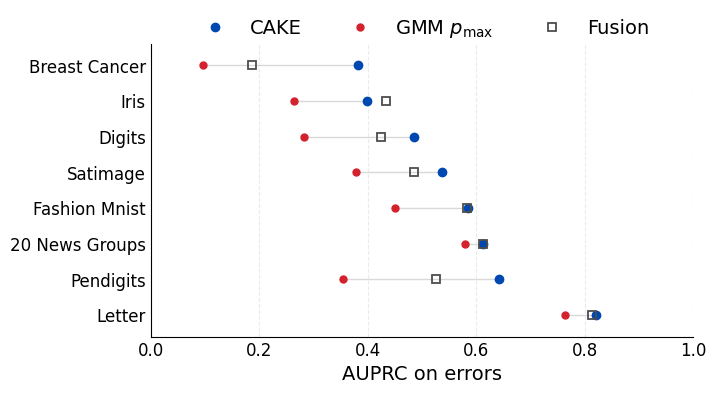

In [ ]:
try:
    align_to_truth
except NameError:
    from sklearn.metrics import confusion_matrix
    from scipy.optimize import linear_sum_assignment
    def align_to_truth(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        r, c = linear_sum_assignment(-cm)
        mapping = {c_: r_ for r_, c_ in zip(r, c)}
        return np.vectorize(mapping.get)(y_pred)

def per_point_correct(y_true, y_pred):
    y_aligned = align_to_truth(y_true, y_pred)
    return (y_aligned == y_true).astype(int)

def gmm_pmax(X, k, cov='full', seed=0):
    gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=seed).fit(X)
    return gmm.predict_proba(X).max(axis=1)

def rank_average(a, b):
    ra = pd.Series(a).rank(pct=True).to_numpy()
    rb = pd.Series(b).rank(pct=True).to_numpy()
    return 0.5*(ra + rb)

def error_discovery_metrics(y_err, conf, budgets=(0.01, 0.02, 0.05, 0.10)):
    n = len(y_err)
    if n == 0 or y_err.min() == y_err.max():
        # Degenerate (all-correct or all-error); metrics not informative
        return np.nan, np.nan, {f'P@{int(b*100)}%': np.nan for b in budgets}

    # Convert to an "error score" where higher = more likely error
    err_score = -conf  # (for pmax also works: low pmax => high err_score)
    ap = float(average_precision_score(y_err, err_score))
    auroc = float(roc_auc_score(y_err, err_score))

    # Precision at small budgets (audit the least-confident k points)
    order = np.argsort(err_score)[::-1]  # highest error score first (lowest confidence)
    prec = {}
    for b in budgets:
        k = max(1, int(round(b * n)))
        idx = order[:k]
        prec[f'P@{int(b*100)}%'] = float(y_err[idx].mean())
    return ap, auroc, prec

R = 20
budgets = (0.01, 0.02, 0.05, 0.10)
rows = []

for ds_name, loader in loaders_real.items():
    X, y = loader()
    X = SimpleImputer(strategy='mean').fit_transform(X) if not hasattr(X, "toarray") else X.toarray()
    k = len(np.unique(y))

    # correctness labels from a stronger reference partition
    ref = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=0).fit_predict(X)
    ycorr = per_point_correct(y, ref)
    y_err = 1 - ycorr  # positives = actual errors

    # confidence signals
    ensemble = [KMeans(n_clusters=k, init='random', n_init=1, random_state=s).fit_predict(X) for s in range(R)]
    cake_scores, _, _, _ = cake(X, ensemble, method='harmonic_mean', approximation=True)  # fast silhouette
    pmax = gmm_pmax(X, k, cov='full' if X.shape[1] <= 5 else 'diag', seed=0)
    fused = rank_average(cake_scores, pmax)

    for name, conf in [('CAKE', cake_scores), ('GMM pmax', pmax), ('Fusion(rank-avg)', fused)]:
        ap, auroc, prec = error_discovery_metrics(y_err, conf, budgets=budgets)
        row = {'dataset': ds_name, 'Score': name, 'AUPRC↑': ap, 'AUROC↑(err)': auroc}
        row.update(prec)
        rows.append(row)

errcmp = pd.DataFrame(rows)

A = (
    errcmp.dropna(subset=['AUPRC↑'])
          .pivot(index='dataset', columns='Score', values='AUPRC↑')
          .reindex(columns=['CAKE','GMM pmax','Fusion(rank-avg)'])
)

prevalence = {}
for ds_name, loader in loaders_real.items():
    X, y = loader()
    X = SimpleImputer(strategy='mean').fit_transform(X) if not hasattr(X, "toarray") else X.toarray()
    k = len(np.unique(y))
    ref = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=0).fit_predict(X)
    ycorr = per_point_correct(y, ref)
    y_err = 1 - ycorr
    prevalence[ds_name] = float(y_err.mean())

baseline = pd.Series(prevalence)

NAME_MAP = {
    'breast_cancer': 'Breast Cancer',
    'iris': 'Iris',
    'digits': 'Digits',
    'satimage': 'Satimage',
    'fashionmnist': 'Fashion Mnist',
    '20newsgroups': '20 News Groups',
    'pendigits': 'Pendigits',
    'letter': 'Letter',
}

if 'dataset' in errcmp.columns:
    errcmp['dataset'] = errcmp['dataset'].map(lambda s: NAME_MAP.get(s, s))

A = A.rename(index=NAME_MAP)
baseline = baseline.rename(index=NAME_MAP)

# Ensure sorted by CAKE
order = A['CAKE'].sort_values(ascending=False).index
A_plot = A.loc[order]
baseline_plot = baseline.loc[order]

y = np.arange(len(A_plot))

plt.rcParams.update({
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.25,
})

fig, ax = plt.subplots(figsize=(7.0, 3.8))

# light connector lines (GMM -> CAKE) per dataset
ax.hlines(y, A_plot['GMM pmax'], A_plot['CAKE'], color='0.85', linewidth=1)

# markers
ax.plot(A_plot['CAKE'], y, 'o', ms=6, color='#0048B1', label='CAKE')
ax.plot(A_plot['GMM pmax'], y, 'o', ms=5, color='#D3212D', label='GMM $p_{\\max}$')
ax.plot(A_plot['Fusion(rank-avg)'], y, 's', ms=6, mfc='none', mec='0.30', mew=1.3, label='Fusion')

# axes labels
ax.set_xlabel('AUPRC on errors')
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlim(0, 1.0)
ax.set_ylim(-0.6, len(y)-0.4)
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.grid(axis='y', visible=False)

# remove tick marks, keep labels
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)

# legend
ax.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15))

plt.show()

## Runtime (s) Comparison on controled synthetic settings
### **Exact vs. Approximate scores**

### vs $R$ (Ensemble Size)

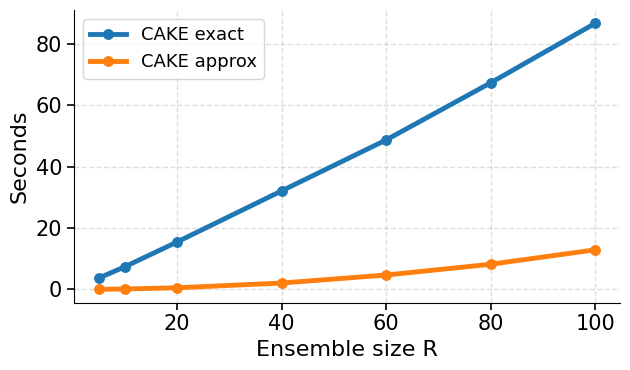


Runtime (sec) & similarity


,R,ensemble_time_sec,cake_exact_sec,cake_approx_sec,pearson,spearman,MAE,RMSE
0,5,0.0465,3.7313,0.0508,0.9744,0.9685,0.0725,0.0848
1,10,0.0672,7.4236,0.1651,0.9722,0.9402,0.0692,0.0750
2,20,0.1335,15.4976,0.5612,0.9751,0.9055,0.0627,0.0663
3,40,0.2518,32.1321,2.1046,0.9553,0.9367,0.0661,0.0696
4,60,0.3752,48.7158,4.7137,0.9439,0.8673,0.0616,0.0642
5,80,0.4963,67.3205,8.2230,0.9363,0.9141,0.0627,0.0657
6,100,0.6351,86.6995,12.9171,0.9144,0.9253,0.0632,0.0663


In [ ]:
R_LIST = (5, 10, 20, 40, 60, 80, 100) # ensemble sizes
N, D, K = 10000, 20, 10 # dataset size
SEED = 0
REPEATS = 1 # timing repeats for smoothing

X, _ = make_blobs(n_samples=N, centers=K, n_features=D, cluster_std=1.0, random_state=SEED)
X = X.astype(np.float32, copy=False)

def build_ensemble(X, k, R):
    labels_list, centers_list = [], []
    t0 = time.perf_counter()
    for s in range(R):
        km = KMeans(n_clusters=k, init="random", n_init=1, random_state=s).fit(X)
        labels_list.append(km.labels_)
        centers_list.append(km.cluster_centers_)
    t_ens = time.perf_counter() - t0
    return labels_list, centers_list, t_ens

def time_cake(X, labels_list, centers_list=None, approx=False, method='harmonic_mean'):
    t0 = time.perf_counter()
    scores, *_ = cake(
        X, labels_list,
        method=method,
        approximation=approx,
        centers_list=centers_list if approx else None
    )
    return scores, (time.perf_counter() - t0)

def top_overlap(a, b, q=0.70):
    k = max(1, int(len(a) * q))
    ia = np.argsort(a)[-k:]
    ib = np.argsort(b)[-k:]
    return len(np.intersect1d(ia, ib)) / k

def safe_pearson(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def safe_spearman(a, b):
    ra = pd.Series(a).rank(method="average")
    rb = pd.Series(b).rank(method="average")
    return safe_pearson(ra.values, rb.values)

rows = []
for R in R_LIST:
    labels_list, centers_list, t_ens = build_ensemble(X, K, R)
    for _ in range(REPEATS):
        gc.collect()

        # approx on full X
        s_approx, t_approx = time_cake(X, labels_list, centers_list=centers_list, approx=True)

        # exact on full X
        s_exact,  t_exact  = time_cake(X, labels_list, approx=False)

        # metrics
        pear   = safe_pearson(s_exact, s_approx)
        spear  = safe_spearman(s_exact, s_approx)
        mae    = float(np.mean(np.abs(s_exact - s_approx)))
        rmse   = float(np.sqrt(np.mean((s_exact - s_approx)**2)))

        rows.append({
            "R": R,
            "ensemble_time_sec": t_ens,
            "cake_exact_sec": t_exact,
            "cake_approx_sec": t_approx,
            "pearson": pear,
            "spearman": spear,
            "MAE": mae,
            "RMSE": rmse
        })

df_time = (pd.DataFrame(rows)
           .groupby("R", as_index=False)
           .mean(numeric_only=True))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(df_time["R"], df_time["cake_exact_sec"],  marker="o", linewidth=3.5, markersize=7, markeredgewidth=0.8, label="CAKE exact")
ax.plot(df_time["R"], df_time["cake_approx_sec"], marker="o", linewidth=3.5, markersize=7, markeredgewidth=0.8, label="CAKE approx")
ax.set_xlabel("Ensemble size R", fontsize=16)
ax.set_ylabel("Seconds", fontsize=16)
ax.set_title(f"", fontsize=16)
ax.tick_params(axis="both", labelsize=15, width=1.2, length=5)
ax.legend(fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle="--", alpha=0.4, linewidth=1.0)
plt.tight_layout(); plt.show()

print("\nRuntime (sec) & similarity")
try:
    display(df_time.round(4))
except NameError:
    print(df_time.round(4).to_string(index=False))

### vs $n$ (Number of Samples)

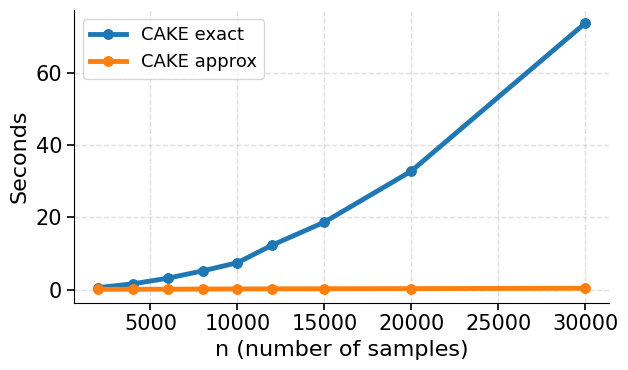

,N,ensemble_time_sec,cake_exact_sec,cake_approx_sec,pearson,spearman,MAE,RMSE
0,2000,0.0248,0.5377,0.0649,0.9772,0.9794,0.0658,0.0694
1,4000,0.0518,1.5978,0.0864,0.9898,0.9702,0.0682,0.0740
2,6000,0.0524,3.1523,0.1070,0.9889,0.9697,0.0642,0.0704
3,8000,0.0563,5.1812,0.1447,0.9740,0.9755,0.0777,0.0835
4,10000,0.0689,7.4471,0.1731,0.9722,0.9402,0.0692,0.0750
5,12000,0.0680,12.3280,0.2021,0.9946,0.9928,0.0522,0.0544
6,15000,0.0819,18.6936,0.2277,0.9941,0.9892,0.0541,0.0586
7,20000,0.1076,32.8486,0.2689,0.9714,0.9512,0.0634,0.0712
8,30000,0.1480,73.8414,0.3563,0.9823,0.9544,0.0564,0.0626


In [ ]:
N_LIST = (2000, 4000, 6000, 8000, 10000, 12000, 15000, 20000, 30000)  # sample sizes
D = 20  # dimensionality
K  = 10 # number of clusters
R = 10  # ensemble size (fixed)
SEED = 0
REPEATS = 10 # timing repeats for smoothing

rows_n = []

for N in N_LIST:

    # Generate synthetic data
    X, _ = make_blobs(
        n_samples=N,
        centers=K,
        n_features=D,
        cluster_std=1.0,
        random_state=SEED
    )
    X = X.astype(np.float32, copy=False)

    labels_list, centers_list, t_ens = build_ensemble(X, K, R)

    for _ in range(REPEATS):
        gc.collect()

        # Approximate CAKE on full X
        s_approx, t_approx = time_cake(
            X,
            labels_list,
            centers_list=centers_list,
            approx=True,
            method='harmonic_mean'   # or 'product', but runtime is similar
        )

        # Exact CAKE on full X
        s_exact, t_exact = time_cake(
            X,
            labels_list,
            centers_list=None,
            approx=False,
            method='harmonic_mean'
        )

        # Similarity metrics between exact and approx
        pear   = safe_pearson(s_exact, s_approx)
        spear  = safe_spearman(s_exact, s_approx)
        mae    = float(np.mean(np.abs(s_exact - s_approx)))
        rmse   = float(np.sqrt(np.mean((s_exact - s_approx)**2)))

        #print(f"  CAKE exact   : {t_exact:.4f} sec")
        #print(f"  CAKE approx  : {t_approx:.4f} sec")
        #print(f"    pearson    : {pear:.4f}, spearman: {spear:.4f}")
        #print(f"    MAE        : {mae:.4f}, RMSE: {rmse:.4f}")

        rows_n.append({
            "N": N,
            "ensemble_time_sec": t_ens,
            "cake_exact_sec": t_exact,
            "cake_approx_sec": t_approx,
            "pearson": pear,
            "spearman": spear,
            "MAE": mae,
            "RMSE": rmse
        })

df_time_n = (pd.DataFrame(rows_n)
             .groupby("N", as_index=False)
             .mean(numeric_only=True))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(df_time_n["N"], df_time_n["cake_exact_sec"],  marker="o", linewidth=3.5, markersize=7, markeredgewidth=0.8, label="CAKE exact")
ax.plot(df_time_n["N"], df_time_n["cake_approx_sec"], marker="o", linewidth=3.5, markersize=7, markeredgewidth=0.8, label="CAKE approx")
ax.set_xlabel("n (number of samples)", fontsize=16)
ax.set_ylabel("Seconds", fontsize=16)
ax.set_title(f"", fontsize=16)
ax.tick_params(axis="both", labelsize=15, width=1.2, length=5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4, linewidth=1.0)
plt.tight_layout()
plt.show()
display(df_time_n.round(4))

## CAKE scores distribution $\sim$ Clustering Algorithm | Ensemble

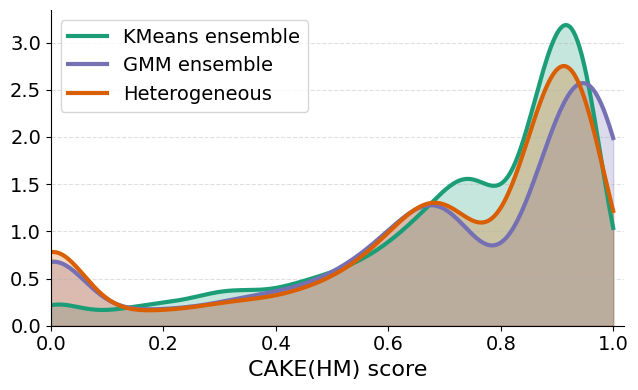

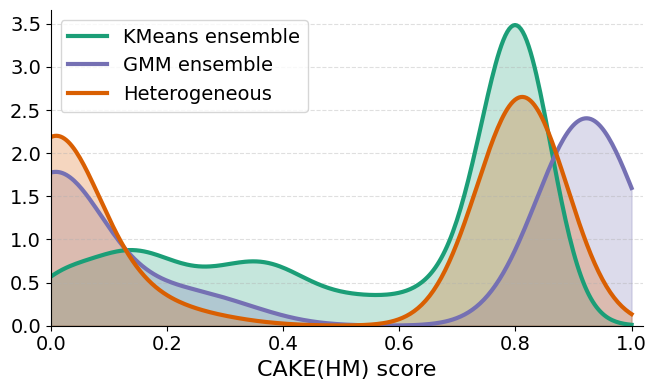

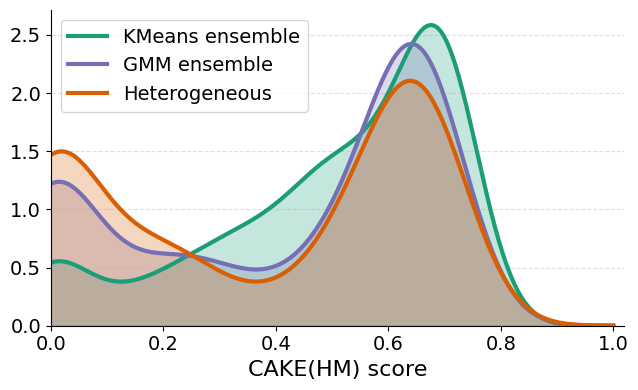

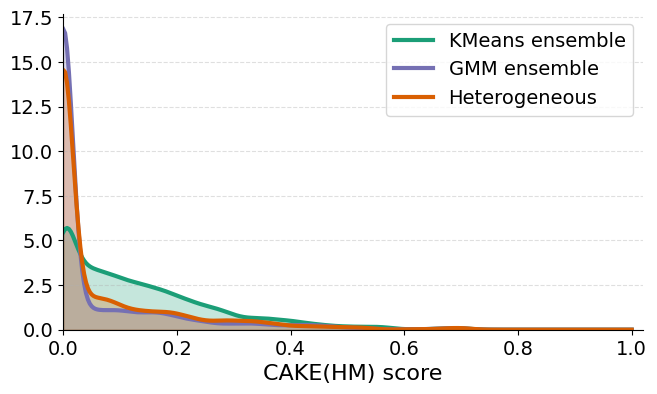

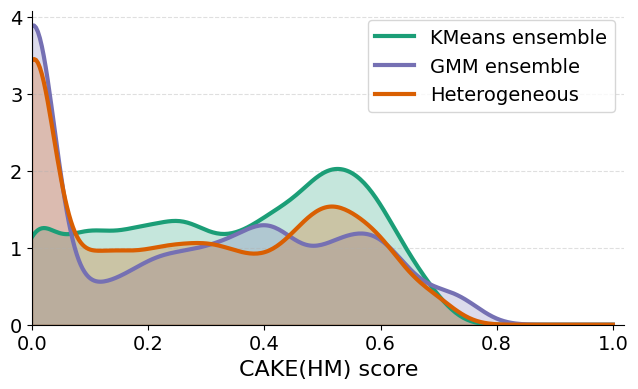

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/589 [00:00<?, ?it/s]

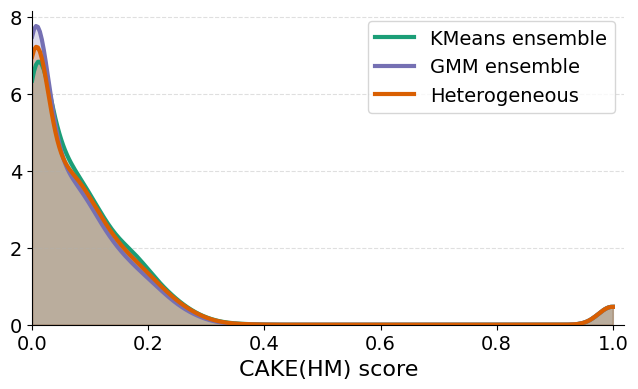

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def build_kmeans_ensemble(X, n_clusters, R=10, base_seed=0):
    labels_list = []
    for r in range(R):
        km = KMeans(
            n_clusters=n_clusters,
            init="k-means++",
            n_init=1,
            random_state=base_seed + r,
        )
        labels_list.append(km.fit_predict(X))
    return labels_list

def build_gmm_ensemble(X, n_clusters, R=10, base_seed=100):
    labels_list = []
    for r in range(R):
        gmm = GaussianMixture(
            n_components=n_clusters,
            covariance_type="full",
            random_state=base_seed + r,
        )
        labels_list.append(gmm.fit(X).predict(X))
    return labels_list

def build_heterogeneous_ensemble(X, n_clusters, R=10, base_seed=200):
    """Alternate KMeans and GMM to get a heterogeneous ensemble."""
    labels_list = []
    for r in range(R):
        seed = base_seed + r
        if r % 2 == 0:
            km = KMeans(
                n_clusters=n_clusters,
                init="k-means++",
                n_init=1,
                random_state=seed,
            )
            labels = km.fit_predict(X)
        else:
            gmm = GaussianMixture(
                n_components=n_clusters,
                covariance_type="full",
                random_state=seed,
            )
            labels = gmm.fit(X).predict(X)
        labels_list.append(labels)
    return labels_list

dataset_keys = ["S5", "S6", "breast_cancer", "letter", "pendigits", "20newsgroups"]

readable_names = {
    "20newsgroups": "20 Newsgroups",
    "satimage": "Satimage",
    "breast_cancer": "Breast Cancer",
    "letter": "Letter",
    "pendigits": "Pendigits",
    "S5": "S5",
    "S6": "S6"
}

for key in dataset_keys:
    if key in loaders_real:
        loader = loaders_real[key]
    else:
        loader = loaders_synth[key]

    X, y = loader()

    if not hasattr(X, "toarray"):
        X = SimpleImputer(strategy="mean").fit_transform(X)
    else:
        X = X.toarray()

    k = len(np.unique(y))

    # build ensembles
    labels_km  = build_kmeans_ensemble(X, k, R=10, base_seed=0)
    labels_gmm = build_gmm_ensemble(X,   k, R=10, base_seed=100)
    labels_het = build_heterogeneous_ensemble(X, k, R=10, base_seed=200)

    # CAKE(HM) scores
    cake_km,  _, _, _ = cake(X, labels_km,  method="harmonic_mean", approximation=False)
    cake_gmm, _, _, _ = cake(X, labels_gmm, method="harmonic_mean", approximation=False)
    cake_het, _, _, _ = cake(X, labels_het, method="harmonic_mean", approximation=False)

    xs = np.linspace(0.0, 1.0, 300)
    curves = [
        (cake_km,  "KMeans ensemble", "#1b9e77"),
        (cake_gmm, "GMM ensemble",  "#7570b3"),
        (cake_het, "Heterogeneous", "#d95f02"),
    ]

    fig, ax = plt.subplots(figsize=(6.5, 4))

    for scores, label, color in curves:
        scores = np.asarray(scores)
        kde = gaussian_kde(scores)
        ys = kde(xs)
        ax.plot(xs, ys, color=color, lw=3, label=label)
        ax.fill_between(xs, ys, 0.0, alpha=0.25, color=color)

    ax.set_xlim(0.0, 1.02)
    ax.set_ylim(bottom=0.0)
    ax.set_xlabel("CAKE(HM) score", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=14)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        title="",
        loc="best",
        frameon=True,
        fontsize=14,
        title_fontsize=10,
    )

    plt.tight_layout()
    plt.show()

## CAKE vs. Entropy-based Agreement and Bootsrap-based Stability

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, average_precision_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr

def aligned_label_entropy_confidence(target_labels, labels_runs, eps=1e-12):
    """
    Entropy of aligned ensemble label distribution.
    Confidence = 1 - H(p_i)/log(k), in [0,1].
    """
    target_labels = np.asarray(target_labels)
    labs = [np.asarray(l) for l in labels_runs]

    aligned = [align_labels(target_labels, l) for l in labs]

    le = LabelEncoder().fit(np.unique(target_labels))
    A = np.vstack([le.transform(a) for a in aligned])  # (R, n)
    R, n = A.shape
    k = len(le.classes_)

    p = np.zeros((n, k), dtype=float)
    for j in range(k):
        p[:, j] = (A == j).mean(axis=0)

    H = -(p * np.log(p + eps)).sum(axis=1)
    conf = 1.0 - (H / np.log(k))
    return np.clip(conf, 0.0, 1.0)

# label alignment
def align_to_truth(y_true, y_pred):
    """Align predicted cluster ids to ground-truth labels via Hungarian matching."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_vals, y_true_enc = np.unique(y_true, return_inverse=True)
    pred_vals, y_pred_enc = np.unique(y_pred, return_inverse=True)

    cm = confusion_matrix(y_true_enc, y_pred_enc)
    r, c = linear_sum_assignment(-cm)

    # mapping: original predicted label -> original true label
    mapping = {pred_vals[cj]: true_vals[ri] for ri, cj in zip(r, c)}

    # map any unmapped pred label to -1 (counts as wrong, avoids crashes)
    return np.array([mapping.get(v, -1) for v in y_pred], dtype=true_vals.dtype)

def align_labels(target, source):
    """Align 'source' labels to 'target' labels."""
    target = np.asarray(target)
    source = np.asarray(source)

    t_vals, t_enc = np.unique(target, return_inverse=True)
    s_vals, s_enc = np.unique(source, return_inverse=True)

    cm = confusion_matrix(t_enc, s_enc)
    r, c = linear_sum_assignment(-cm)

    mapping = {s_vals[cj]: t_vals[ri] for ri, cj in zip(r, c)}
    return np.array([mapping.get(v, -1) for v in source], dtype=t_vals.dtype)

# bootstrap stability
def compute_bootstrap_stability_kmeans(
    X,
    n_clusters,
    n_runs=20,
    sample_fraction=0.8,
    random_state=None,
    kmeans_kwargs=None,
):
    """
    Subsampling-based (bootstrap-style) per-point stability using K-means.
    """
    X = np.asarray(X)
    n_samples = X.shape[0]

    if not (0.0 < sample_fraction <= 1.0):
        raise ValueError("sample_fraction must be in (0, 1].")

    if kmeans_kwargs is None:
        kmeans_kwargs = {}

    rng = np.random.RandomState(random_state)
    subset_size = max(2, int(round(sample_fraction * n_samples)))

    all_labels = []
    all_included = []

    for _ in range(n_runs):
        idx = rng.choice(n_samples, size=subset_size, replace=False)
        X_sub = X[idx]

        km = KMeans(
            n_clusters=n_clusters,
            init=kmeans_kwargs.get("init", "k-means++"),
            n_init=kmeans_kwargs.get("n_init", 1),
            random_state=rng.randint(0, 10**9),
        )
        labels_sub = km.fit_predict(X_sub)

        labels_full = np.full(n_samples, fill_value=-1, dtype=int)
        labels_full[idx] = labels_sub

        all_labels.append(labels_full)
        all_included.append(labels_full != -1)

    all_labels = np.stack(all_labels, axis=0)      # (R, n)
    all_included = np.stack(all_included, axis=0)  # (R, n)

    match_counts = np.zeros(n_samples, dtype=float)
    pair_counts = np.zeros(n_samples, dtype=float)

    R = n_runs
    for r1 in range(R):
        labels1 = all_labels[r1]
        inc1 = all_included[r1]
        for r2 in range(r1 + 1, R):
            labels2 = all_labels[r2]
            inc2 = all_included[r2]

            common = inc1 & inc2
            if not np.any(common):
                continue

            idx_common = np.where(common)[0]
            lab1_common = labels1[idx_common]
            lab2_common = labels2[idx_common]

            aligned2 = align_labels(lab1_common, lab2_common)
            matches = (lab1_common == aligned2)

            match_counts[idx_common] += matches.astype(float)
            pair_counts[idx_common] += 1.0

    with np.errstate(divide="ignore", invalid="ignore"):
        stability = np.where(pair_counts > 0.0, match_counts / pair_counts, 0.0)

    return stability

# Helpers
def remap_pred_to_true(y_true, y_pred):
    """
    Remap predicted cluster labels to true labels via Hungarian matching.
    Returns y_pred mapped into y_true label space.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    le_t = LabelEncoder().fit(y_true)
    le_p = LabelEncoder().fit(y_pred)

    yt = le_t.transform(y_true)
    yp = le_p.transform(y_pred)

    cm = confusion_matrix(yt, yp)
    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {le_p.classes_[c]: le_t.classes_[r] for r, c in zip(row_ind, col_ind)}
    y_pred_remap = np.vectorize(mapping.get)(y_pred)
    return y_pred_remap

def get_metrics(correct01, score_vec):
    ap = average_precision_score(correct01, score_vec)
    if len(np.unique(correct01)) < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(correct01, score_vec)
    return ap, auc

# Compute per-dataset scores
ensemble_size = 20
metric_to_plot = "AUC"   # "AP" or "AUC"

# bootstrap settings
bootstrap_runs = 20
bootstrap_sample_fraction = 0.8
bootstrap_random_state = 42

rows = []
for name, loader in loaders_synth.items():
    print(f"Processing dataset: {name}")
    X, y = loader()

    if not hasattr(X, "toarray"):
        X = SimpleImputer(strategy="mean").fit_transform(X)
    else:
        X = X.toarray()

    k = len(np.unique(y))

    # build ensemble
    ensemble = [
        KMeans(n_clusters=k, init="random", n_init=1, random_state=seed).fit_predict(X)
        for seed in range(ensemble_size)
    ]

    # CAKE components
    cake_pr, stability, geom_stability, _ = cake(X, ensemble, method="product")
    cake_hm = (2.0 * stability * geom_stability) / np.maximum(stability + geom_stability, 1e-12)

    # consensus and correctness definition (positive = consensus correct)
    z_star, agree_scores = consensus_medoid_majority(ensemble)
    z_star_remap = remap_pred_to_true(y, z_star)
    correct01 = (z_star_remap == y).astype(int)

    # entropy confidence (aligned to consensus)
    entropy_conf = aligned_label_entropy_confidence(z_star, ensemble)

    # bootstrap stability (subsampling KMeans)
    boot = compute_bootstrap_stability_kmeans(
        X,
        n_clusters=k,
        n_runs=bootstrap_runs,
        sample_fraction=bootstrap_sample_fraction,
        random_state=bootstrap_random_state,
        kmeans_kwargs={"init": "k-means++", "n_init": 1},
    )


    ap_pr, auc_pr = get_metrics(correct01, cake_pr)
    ap_hm, auc_hm = get_metrics(correct01, cake_hm)
    ap_en, auc_en = get_metrics(correct01, entropy_conf)
    ap_bt, auc_bt = get_metrics(correct01, boot)

    rows.append({
        "dataset": name,

        "CAKE(PR)_AUC": auc_pr,
        "CAKE(HM)_AUC": auc_hm,
        "Entropy-align_AUC": auc_en,
        "Bootstrap stability_AUC": auc_bt,

        "CAKE(PR)_AP": ap_pr,
        "CAKE(HM)_AP": ap_hm,
        "Entropy-align_AP": ap_en,
        "Bootstrap stability_AP": ap_bt,
    })

all_df = pd.DataFrame(rows).set_index("dataset").sort_index()
dataset_keys = all_df.index.tolist()
readable_names = dataset_keys

methods = ["CAKE(PR)", "CAKE(HM)", "Entropy-align", "Bootstrap stability"]

auc_df = all_df[[f"{m}_AUC" for m in methods]].copy()
ap_df  = all_df[[f"{m}_AP"  for m in methods]].copy()

auc_df.columns = methods
ap_df.columns  = methods

one_table = pd.concat({"AUC": auc_df, "AP": ap_df}, axis=0)
one_table.index.names = ["metric", "dataset"]
one_table = one_table.swaplevel(0, 1).sort_index()   # (dataset, metric)

display(one_table.round(3))

Processing dataset: S1
Processing dataset: S2
Processing dataset: S3
Processing dataset: S4
Processing dataset: S5
Processing dataset: S6
Processing dataset: S7


CAKE(PR)  CAKE(HM)  Entropy-align  Bootstrap stability
dataset metric                                                        
S1      AP         0.997     0.997          0.958                0.960
        AUC        0.932     0.932          0.506                0.519
S2      AP         0.930     0.931          0.785                0.807
        AUC        0.761     0.764          0.488                0.553
S3      AP         0.934     0.935          0.850                0.801
        AUC        0.846     0.848          0.729                0.642
S4      AP         0.976     0.976          0.887                0.889
        AUC        0.843     0.843          0.514                0.528
S5      AP         0.978     0.980          0.904                0.908
        AUC        0.823     0.834          0.499                0.509
S6      AP         0.923     0.924          0.763                0.754
        AUC        0.821     0.823          0.657                0.621
S7      AP         0.975     0.977          0.933                0.919
        AUC        0.817     0.826          0.602                0.575

In [ ]:
# Compute per-dataset scores
ensemble_size = 20
metric_to_plot = "AUC"   # "AP" or "AUC"

# bootstrap settings
bootstrap_runs = 20
bootstrap_sample_fraction = 0.8
bootstrap_random_state = 42

rows = []
for name, loader in loaders_real.items():
    print(f"Processing dataset: {name}")
    X, y = loader()

    if not hasattr(X, "toarray"):
        X = SimpleImputer(strategy="mean").fit_transform(X)
    else:
        X = X.toarray()

    k = len(np.unique(y))

    # build ensemble
    ensemble = [
        KMeans(n_clusters=k, init="random", n_init=1, random_state=seed).fit_predict(X)
        for seed in range(ensemble_size)
    ]

    # CAKE components
    cake_pr, stability, geom_stability, _ = cake(X, ensemble, method="product")
    cake_hm = (2.0 * stability * geom_stability) / np.maximum(stability + geom_stability, 1e-12)

    # consensus and correctness definition (positive = consensus correct)
    z_star, agree_scores = consensus_medoid_majority(ensemble)
    z_star_remap = remap_pred_to_true(y, z_star)
    correct01 = (z_star_remap == y).astype(int)

    # entropy confidence (aligned to consensus)
    entropy_conf = aligned_label_entropy_confidence(z_star, ensemble)

    # bootstrap stability (subsampling KMeans)
    boot = compute_bootstrap_stability_kmeans(
        X,
        n_clusters=k,
        n_runs=bootstrap_runs,
        sample_fraction=bootstrap_sample_fraction,
        random_state=bootstrap_random_state,
        kmeans_kwargs={"init": "k-means++", "n_init": 1},
    )


    ap_pr, auc_pr = get_metrics(correct01, cake_pr)
    ap_hm, auc_hm = get_metrics(correct01, cake_hm)
    ap_en, auc_en = get_metrics(correct01, entropy_conf)
    ap_bt, auc_bt = get_metrics(correct01, boot)

    rows.append({
        "dataset": name,

        "CAKE(PR)_AUC": auc_pr,
        "CAKE(HM)_AUC": auc_hm,
        "Entropy-align_AUC": auc_en,
        "Bootstrap stability_AUC": auc_bt,

        "CAKE(PR)_AP": ap_pr,
        "CAKE(HM)_AP": ap_hm,
        "Entropy-align_AP": ap_en,
        "Bootstrap stability_AP": ap_bt,
    })

all_df = pd.DataFrame(rows).set_index("dataset").sort_index()
dataset_keys = all_df.index.tolist()
readable_names = dataset_keys

methods = ["CAKE(PR)", "CAKE(HM)", "Entropy-align", "Bootstrap stability"]

auc_df = all_df[[f"{m}_AUC" for m in methods]].copy()
ap_df  = all_df[[f"{m}_AP"  for m in methods]].copy()

auc_df.columns = methods
ap_df.columns  = methods

one_table = pd.concat({"AUC": auc_df, "AP": ap_df}, axis=0)
one_table.index.names = ["metric", "dataset"]
one_table = one_table.swaplevel(0, 1).sort_index()   # (dataset, metric)

display(one_table.round(3))

Processing dataset: iris
Processing dataset: breast_cancer
Processing dataset: digits
Processing dataset: 20newsgroups


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

Processing dataset: fashionmnist
Processing dataset: pendigits
Processing dataset: letter
Processing dataset: satimage


CAKE(PR)  CAKE(HM)  Entropy-align  Bootstrap stability
dataset       metric                                                        
20newsgroups  AP         0.638     0.624          0.623                0.637
              AUC        0.678     0.669          0.636                0.637
breast_cancer AP         0.971     0.971          0.915                0.929
              AUC        0.773     0.773          0.555                0.636
digits        AP         0.909     0.912          0.734                0.869
              AUC        0.767     0.777          0.526                0.717
fashionmnist  AP         0.758     0.755          0.631                0.751
              AUC        0.707     0.703          0.667                0.742
iris          AP         0.977     0.984          0.859                0.923
              AUC        0.840     0.888          0.328                0.675
letter        AP         0.465     0.465          0.402                0.409
              AUC        0.661     0.664          0.617                0.602
pendigits     AP         0.951     0.954          0.900                0.864
              AUC        0.857     0.866          0.769                0.718
satimage      AP         0.890     0.894          0.706                0.725
              AUC        0.784     0.788          0.560                0.592

## CAKE on non-convex data (Moons)
### **Spectral Ensemble**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances, confusion_matrix
from scipy.optimize import linear_sum_assignment
from matplotlib.tri import Triangulation

def align_labels(target, source):
    target = np.asarray(target); source = np.asarray(source)
    lt = LabelEncoder().fit(target); ls = LabelEncoder().fit(source)
    t = lt.transform(target); s = ls.transform(source)
    C = confusion_matrix(t, s)
    r, c = linear_sum_assignment(-C)
    mapping = {ls.classes_[cj]: lt.classes_[ri] for ri, cj in zip(r, c)}
    return np.vectorize(mapping.get)(source)

def pairwise_stability(labels_runs):
    labels_runs = [np.asarray(l) for l in labels_runs]
    n_runs = len(labels_runs); n = labels_runs[0].shape[0]
    agree = np.zeros(n, dtype=int); total = 0
    for i in range(n_runs):
        li = labels_runs[i]
        for j in range(i+1, n_runs):
            lj = align_labels(li, labels_runs[j])
            agree += (li == lj); total += 1
    return agree / max(total, 1)

# Kernelized Silhouette with centroid-in-RKHS from precomputed Gram K
def kernel_centroid_silhouette_samples_from_K(K, labels):
    K = np.asarray(K); n = K.shape[0]
    labels = np.asarray(labels)
    le = LabelEncoder().fit(labels); z = le.transform(labels); k = le.classes_.size
    if k < 2: raise ValueError("Silhouette requires >=2 clusters.")
    k_xx = np.clip(np.diag(K), 0.0, None)
    idxs = [np.where(z == c)[0] for c in range(k)]
    sizes = np.array([len(ix) for ix in idxs], int)
    sum_CC = np.array([K[np.ix_(ix, ix)].sum() for ix in idxs], float)
    sum_iC = [K[:, ix].sum(axis=1) for ix in idxs]
    D2 = np.empty((n, k), float)
    for c, ix in enumerate(idxs):
        m = float(sizes[c])
        D2[:, c] = k_xx - (2.0/m) * sum_iC[c] + (sum_CC[c] / (m*m))
    own = D2[np.arange(n), z]
    D2_others = D2.copy(); D2_others[np.arange(n), z] = np.inf
    near = np.min(D2_others, axis=1)
    a = np.sqrt(np.maximum(own, 0.0)); b = np.sqrt(np.maximum(near, 0.0))
    denom = np.maximum(np.maximum(a, b), 1e-12)
    s = (b - a) / denom
    s[sizes[z] < 2] = 0.0
    return np.clip(s, -1.0, 1.0)

def sil_kernel_stats_from_K(K, labels_list):
    S = np.vstack([kernel_centroid_silhouette_samples_from_K(K, z) for z in labels_list])
    return S.mean(axis=0), S.std(axis=0)

# Self-tuning RBF kernel
def self_tuning_kernel(X, k_nn=7, eps=1e-12):
    D = pairwise_distances(X, squared=False)
    idx = np.argsort(D, axis=1)
    knn_idx = idx[:, k_nn]  # distance to k_nn-th nearest neighbor
    sigma = np.maximum(D[np.arange(D.shape[0]), knn_idx], eps)
    S = sigma[:, None] * sigma[None, :]
    K = np.exp(-(D**2) / np.maximum(S, eps))
    return 0.5 * (K + K.T)

# Data (+ a few outliers)
rng = np.random.default_rng(7)
X, y_true = make_moons(n_samples=1200, noise=0.06, random_state=0)

# Inject a small uniform noise
phi = 0.03  # 3% outliers
lo, hi = X.min(0), X.max(0); pad = 0.10 * (hi - lo)
U = rng.uniform(lo - pad, hi + pad, size=(int(phi * len(X)), X.shape[1]))
X = np.vstack([X, U])
is_noise = np.r_[np.zeros(len(X) - len(U), dtype=bool), np.ones(len(U), dtype=bool)]

# Spectral ensemble (hard labels + randomness)
def one_spectral_run(seed):
    # jitter neighbors to induce controlled diversity in the ensemble
    nn = int(rng.integers(10, 16))
    A = kneighbors_graph(X, n_neighbors=nn, include_self=True, mode='connectivity')
    A = 0.5 * (A + A.T)
    sc = SpectralClustering(
        n_clusters=2, affinity='precomputed',
        assign_labels='kmeans', n_init=1, random_state=seed
    )
    return sc.fit_predict(A)

R = 25
labels_list = [one_spectral_run(seed) for seed in range(R)]
labels_one = labels_list[0]

c = pairwise_stability(labels_list)

# Geometry via kernelized Silhouette (self-tuning RBF)
K = self_tuning_kernel(X, k_nn=7)
muS, sdS = sil_kernel_stats_from_K(K, labels_list)

# Clip (preserve negatives as 0) and normalize for contrast
geom_raw = muS - sdS
Sg = np.maximum(geom_raw, 0.0)
Sg /= (Sg.max() + 1e-12)
cake = c * Sg

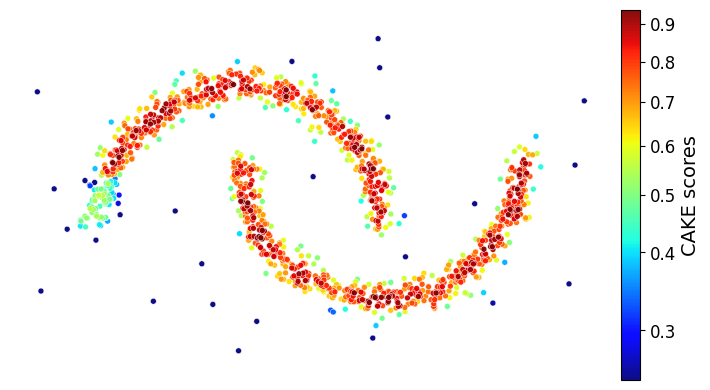

In [ ]:
from matplotlib.colors import PowerNorm

order = np.argsort(cake)

vmin, vmax = np.quantile(cake, 0.02), np.quantile(cake, 0.98)
norm = PowerNorm(gamma=0.65, vmin=vmin, vmax=vmax)

plt.figure(figsize=(7.2, 6.0))
sc = plt.scatter(
    X[order, 0], X[order, 1],
    c=cake[order],
    cmap="jet",
    norm=norm,
    s=18, alpha=0.95,
    linewidths=0.35, edgecolors="white",
    rasterized=True
)

cb = plt.colorbar(sc, shrink=0.65, fraction=0.04, pad=0.015)
cb.set_label("CAKE scores", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.title("", fontsize=16)
plt.gca().set_aspect("equal", "box")
plt.xticks([]); plt.yticks([])
for spine in ["top", "right", "left", "bottom"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()